In [1]:
import numpy as np 
import pandas as pd 
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Ignorer tous les avertissements (utilisez avec précaution)
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv("data_after_filtering-3.csv")

In [3]:
data.Test_2.value_counts()

Test_2
Valide    1146
refus      987
Name: count, dtype: int64

In [4]:
column_to_drop = ['Machine', 'Pneumatique','Nom du Curseur','Seuil de départ', 'Position/Axe', 'Décalage/Axe', 
                  'Date_txt', 'Heure_txt','Pas Min [m]', 'Pas Max [m]', 'Moyenne Vitesse [Km/h]','Moyenne CFL F', 'Fv (kg)',
                  'Tsurf (V)', 'ET CFLF', 'Ic CFL C', 'ET Fv', 'Ic Fv', 'T° BDR (V)', 
                  'Test','180 - Fv']

- Les colonnes supprimées ci-dessus n'ont pas d'importance dans cette analyse, mais elles sont cruciales lors de l'étape de la modélisation.
- Pour l'instant, nous allons déterminer s'il y a de la répétabilité et de la reproductibilité. Autrement dit, pour chaque passage, obtenons-nous les mêmes résultats ? Sachant que chaque passage est divisé en partitions de 20 mètres, est-ce que tous les 20 mètres d'un passage donnent les mêmes résultats ?
  - Cette étude est importante pour évaluer la qualité des données et vérifier que les résultats ne sont pas rassemblés de manière aléatoire.
  - L'objectif final est d'optimiser la performance du modèle de prédiction final, qu'il s'agisse de classification ou de régression.


In [5]:
df = data.copy()
df.drop(column_to_drop, axis = 1, inplace = True)
df['Date'] = pd.to_datetime(df['Date'])
df_valide = df[df.Test_2 == "Valide"]

In [6]:
df_valide.columns

Index(['Vitesse', 'Date', 'Heure', 'Glissement', 'Moyenne CFL C',
       'Moyenne G% [%]', 'ET G%', 'Ic G%', 'ET CFLC', 'Contaminant',
       'hauteur (mm)', 'Test_2'],
      dtype='object')

### Reproductibilité

Un passage est défini par un contaminant donné, une vitesse donnée, un glissement donné et une heure donnée.  
Pour garantir la reproductibilité, il est nécessaire que les valeurs pour chaque passage soient homogènes (les valeurs de chaque segment de 20 mètres doivent être homogènes). Statistiquement parlant, cela signifie que l'écart-type de ces valeurs doit être faible.

In [7]:
def seuil(x):
    if x < 0.03:
        return 0.01
    elif x < 0.1:
        return 0.02
    else:
        return 0.03

            
# Supposons que df_valide soit votre DataFrame
result = df_valide.groupby(['Contaminant', 'Vitesse', 'Glissement', 'Heure'])['Moyenne CFL C'].agg(
    mean='mean',
    std='std'
).fillna(0)

# Appliquer la fonction seuil à la colonne 'mean' résultante
result['Seuil'] = result['std'].apply(seuil)
result.shape

(222, 3)

Il est important de noter que, compte tenu du grand nombre de groupes, visualiser les écarts-types dans un graphique est une très mauvaise idée. Cela entraînerait un graphique très chaotique, comme celui ci-dessous.

In [8]:
def Reproductibilite(vitesse):
    # Calculer l'écart-type des groupes et renommer la colonne résultante en 'Écart-Type-CFL C'
    df_grouped = df_valide[df_valide.Contaminant != "DRY"].groupby(['Contaminant', 'Vitesse', 'Glissement',"Heure"])['Moyenne CFL C'].agg(
        mean=np.mean,
        std=np.std,
    ).fillna(0).reset_index()
    df_grouped['Seuil'] = df_grouped['mean'].apply(seuil)
    # Filtrer pour une vitesse donnée (par exemple 40)
    vitesse_donnee = vitesse

    df_filtered = df_grouped[df_grouped['Vitesse'] == vitesse_donnee]
    
    # Convertir les colonnes 'Glissement' et 'Heure' en type chaîne de caractères
    df_filtered['Glissement'] = df_filtered['Glissement'].astype(str)
    df_filtered['Heure'] = df_filtered['Heure'].astype(str)
    
    # Fusionner 'Glissement' et 'Heure' pour une légende plus détaillée
    df_filtered['Glissement_Heure'] = df_filtered['Glissement'] + ' - ' + df_filtered['Heure']
    
    # Configuration du graphique
    plt.figure(figsize=(14, 6))
    barplot = sns.barplot(data=df_filtered, x='Contaminant', y='std', hue='Glissement_Heure', palette='Set2')
    
    # Ajouter des labels et un titre
    plt.xlabel('Contaminant')
    plt.ylabel('Ecart type de CFL C')
    plt.title(f'Ecart type par Contaminant pour Vitesse = {vitesse_donnee}')
    plt.legend(title='Glissement - Heure', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    
    # Définir les limites de l'axe y
    plt.ylim(0, 0.08)  # Ajustez le facteur selon vos besoins

    plt.show()


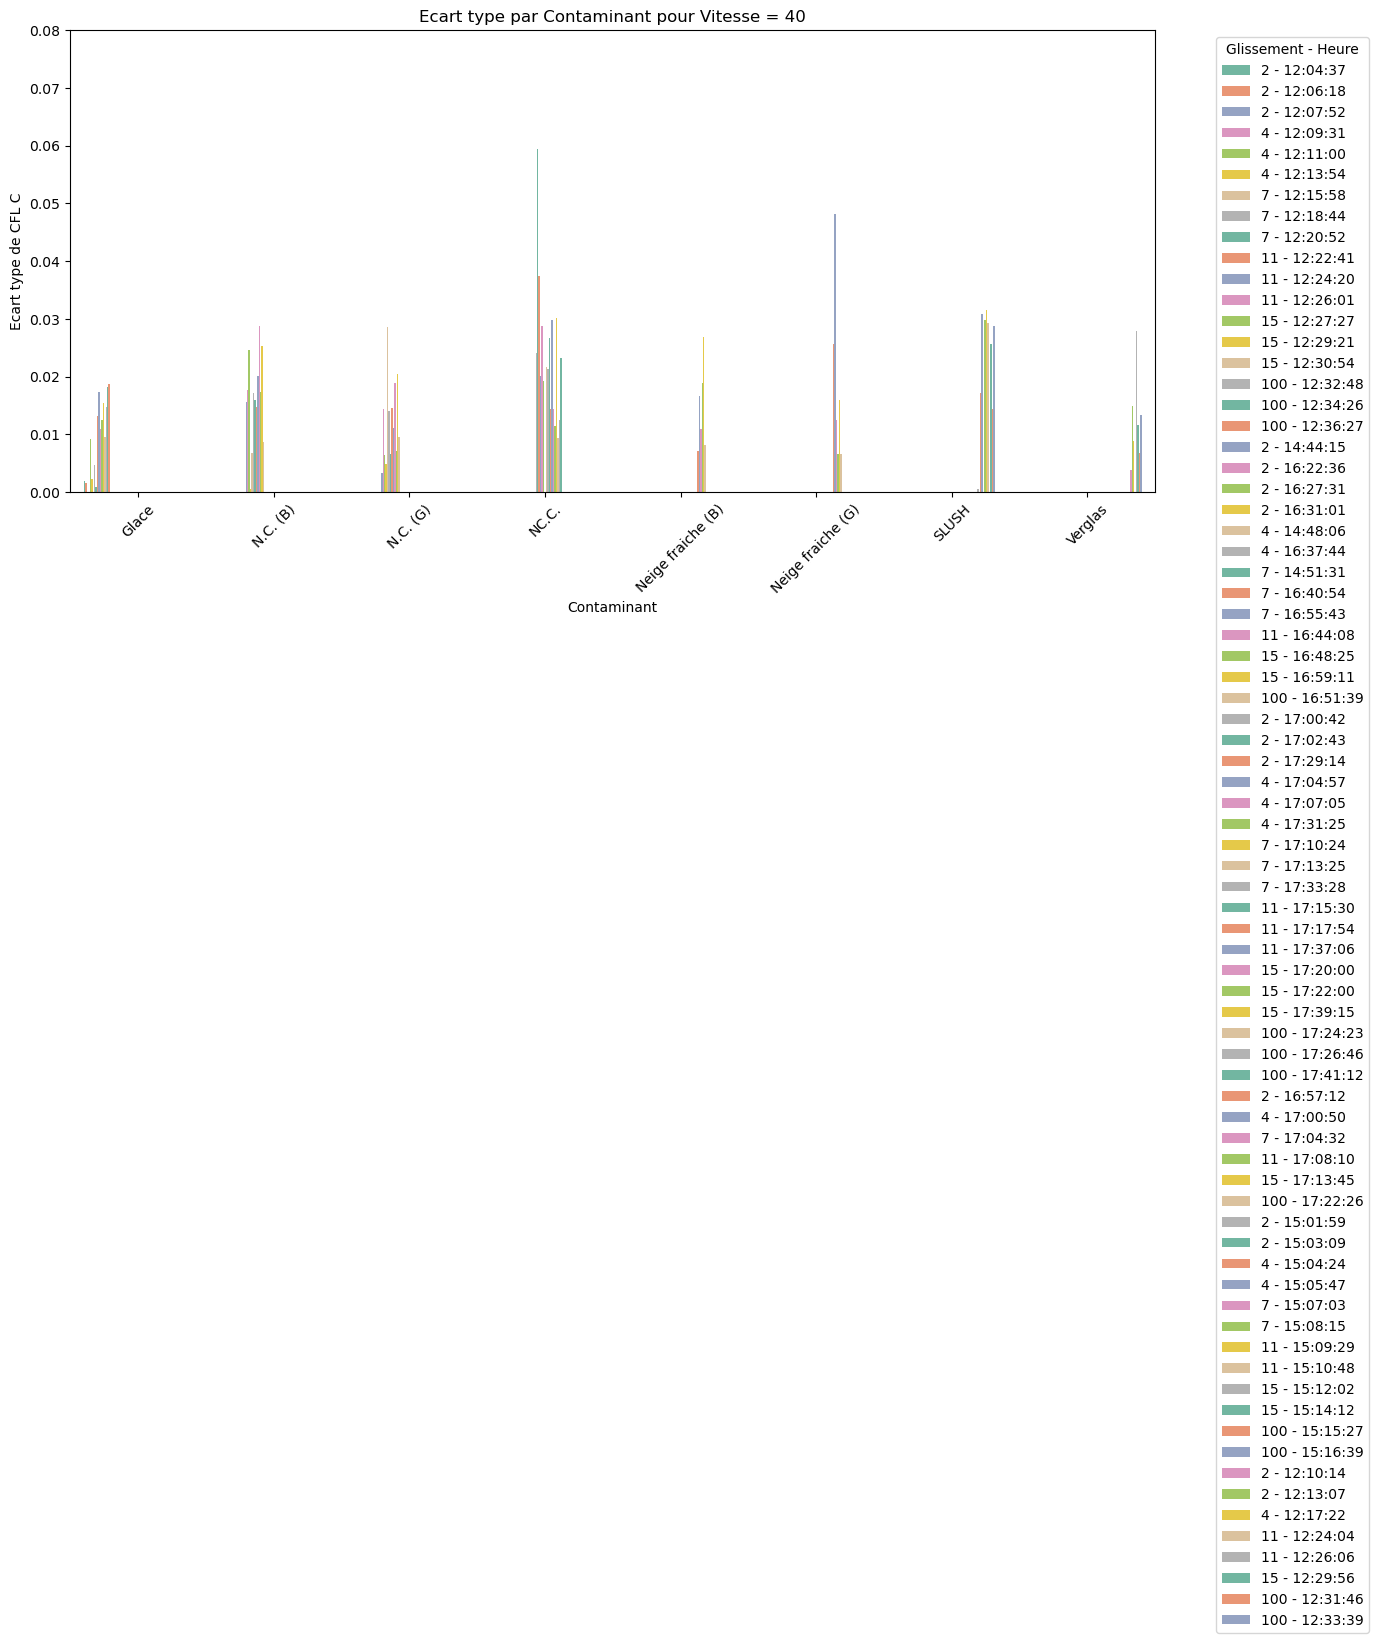

In [9]:
Reproductibilite(40)

C'est pourquoi, pour analyser les valeurs des écarts-types, nous allons examiner directement la table de données.  

La prochaine étape consiste à identifier la source de ce problème et à le résoudre.

In [10]:
df_grouped_rp = df_valide.groupby(['Contaminant', 'Vitesse', 'Glissement',"Heure"])['Moyenne CFL C'].agg(
        mean=np.mean,
        std=np.std,
    ).fillna(0)
df_grouped_rp['Seuil'] = df_grouped_rp['mean'].apply(seuil)
df_grouped_rp.loc[df_grouped_rp['std']> df_grouped_rp['Seuil']]

mean       std  Seuil
Contaminant       Vitesse Glissement Heure                              
Glace             65      100        11:58:22  0.075520  0.024693   0.02
N.C. (B)          40      2          16:27:31  0.096905  0.024692   0.02
                  65      4          15:24:42  0.080857  0.026129   0.02
                          7          15:35:03  0.172159  0.041586   0.03
N.C. (G)          65      4          15:19:04  0.078748  0.040219   0.02
                          7          15:35:03  0.162205  0.041805   0.03
                          11         15:46:02  0.191154  0.044479   0.03
                                     15:51:25  0.146778  0.048247   0.03
                          15         15:55:27  0.150221  0.034155   0.03
                                     16:04:50  0.159125  0.040992   0.03
NC.C.             40      2          17:00:42  0.091762  0.024112   0.02
                                     17:02:43  0.076450  0.059431   0.02
                                     17:29:14  0.078130  0.037470   0.02
                          15         17:39:15  0.247536  0.030147   0.03
                  65      4          16:50:56  0.053349  0.042149   0.02
                          7          16:31:52  0.208595  0.044453   0.03
Neige fraiche (G) 40      2          16:57:12  0.051476  0.025615   0.02
                          4          17:00:50  0.082845  0.048101   0.02
SLUSH             40      4          15:04:24  0.011479  0.017105   0.01
                                     15:05:47  0.033558  0.030792   0.02
                          7          15:08:15  0.032357  0.029732   0.02
                          11         15:09:29  0.160413  0.031599   0.03
                  65      2          14:47:17  0.007286  0.010304   0.01
                          4          14:49:48  0.037794  0.033731   0.02
                          7          14:53:38  0.068810  0.024513   0.02
                          11         14:55:57  0.055259  0.038913   0.02
                          15         14:57:04  0.058833  0.049396   0.02
                                     14:58:13  0.080762  0.063229   0.02

In [11]:
l=[]
ll=[]

## Glace

In [12]:
# Glace 65 100

In [13]:
df_valide[(df_valide["Contaminant"] == "Glace") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 100) & (df_valide["Heure"] == "11:58:22")]

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1835,65,2024-01-19,11:58:22,100,0.105650,99.055500,0.666440,0.310857,0.059865,Glace,0.0,Valide
1836,65,2024-01-19,11:58:22,100,0.098476,99.288095,0.399107,0.186161,0.034270,Glace,0.0,Valide
1837,65,2024-01-19,11:58:22,100,0.057714,99.738095,0.163420,0.076226,0.011950,Glace,0.0,Valide
1838,65,2024-01-19,11:58:22,100,0.052190,99.812381,0.138452,0.064580,0.008477,Glace,0.0,Valide
1839,65,2024-01-19,11:58:22,100,0.063571,99.660952,0.346264,0.161513,0.013381,Glace,0.0,Valide


In [14]:
l+=[1835, 1836]
ll+=[1835, 1836]
print(len(l), len(ll))

2 2


On supprime 1835, 1836 (instables)

## NCB

In [15]:
# NCB 40 2

In [16]:
df_valide[(df_valide["Contaminant"] == "N.C. (B)") & (df_valide["Vitesse"] == 40) & (df_valide["Glissement"] == 2) & (df_valide["Heure"] == "16:27:31")]

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
672,40,2024-01-17,16:27:31,2,0.070333,0.794762,0.185057,0.086319,0.009536,N.C. (B),15.75,Valide
673,40,2024-01-17,16:27:31,2,0.101238,1.211429,0.254013,0.118483,0.009518,N.C. (B),15.75,Valide
674,40,2024-01-17,16:27:31,2,0.119143,1.934286,0.493331,0.230111,0.004953,N.C. (B),15.75,Valide


In [17]:
l+=[]
ll+=[672]
print(len(l), len(ll))

2 3


On supprime 672

In [18]:
# NCB 65 4

In [19]:
df_valide[(df_valide["Contaminant"] == "N.C. (B)") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 4) & (df_valide["Heure"] == "15:24:42")]

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
869,65,2024-01-17,15:24:42,4,0.099333,4.741429,1.374585,0.641166,0.008416,N.C. (B),15.75,Valide
872,65,2024-01-17,15:24:42,4,0.062381,3.385238,1.100884,0.513501,0.004236,N.C. (B),15.75,Valide


In [20]:
l+=[]
ll+=[869]
print(len(l), len(ll))

2 4


On supprime 672

In [21]:
# NCB 65 4

In [22]:
df_valide[(df_valide["Contaminant"] == "N.C. (B)") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 7) & (df_valide["Heure"] == "15:35:03")]

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
909,65,2024-01-17,15:35:03,7,0.125429,4.448095,1.290247,0.601827,0.026016,N.C. (B),15.75,Valide
910,65,2024-01-17,15:35:03,7,0.205095,5.775238,1.286587,0.600121,0.026059,N.C. (B),15.75,Valide
915,65,2024-01-17,15:35:03,7,0.185952,7.046190,0.869382,0.405518,0.012319,N.C. (B),15.75,Valide


In [23]:
l+=[]
ll+=[909]
print(len(l), len(ll))

2 5


On supprime 909 	

## NCG

In [24]:
# NCG 65 4

In [25]:
df_valide[(df_valide["Contaminant"] == "N.C. (G)") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 4) & (df_valide["Heure"] == "15:19:04")]

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
832,65,2024-01-17,15:19:04,4,0.125150,3.692000,1.384932,0.645993,0.017491,N.C. (G),15.83,Valide
835,65,2024-01-17,15:19:04,4,0.057190,3.021905,1.916600,0.893986,0.006013,N.C. (G),15.83,Valide
837,65,2024-01-17,15:19:04,4,0.053905,5.521429,1.887393,0.880363,0.008012,N.C. (G),15.83,Valide


In [26]:
l+=[832]
ll+=[832]
print(len(l), len(ll))

3 6


On supprime 832

In [27]:
# NCG 65 7

In [28]:
df_valide[(df_valide["Contaminant"] == "N.C. (G)") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 7) & (df_valide["Heure"] == "15:35:03")]

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
902,65,2024-01-17,15:35:03,7,0.194429,7.822857,1.706309,0.795897,0.036015,N.C. (G),15.83,Valide
903,65,2024-01-17,15:35:03,7,0.173500,6.827500,1.888998,0.881111,0.025843,N.C. (G),15.83,Valide
905,65,2024-01-17,15:35:03,7,0.168571,6.730476,1.367456,0.637841,0.010308,N.C. (G),15.83,Valide
906,65,2024-01-17,15:35:03,7,0.184905,6.810476,1.582427,0.738113,0.026258,N.C. (G),15.83,Valide
908,65,2024-01-17,15:35:03,7,0.089619,11.852857,2.567069,1.197393,0.036849,N.C. (G),15.83,Valide


In [29]:
l+=[908]
ll+=[908]
print(len(l), len(ll))

4 7


On supprime 908

In [30]:
# NCG 65 7

In [31]:
df_valide[(df_valide["Contaminant"] == "N.C. (G)") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 11) & (df_valide["Heure"] == "15:46:02")]

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
916,65,2024-01-17,15:46:02,11,0.215150,11.486000,1.818294,0.848132,0.039946,N.C. (G),15.83,Valide
917,65,2024-01-17,15:46:02,11,0.156190,12.018095,2.431634,1.134221,0.034863,N.C. (G),15.83,Valide
918,65,2024-01-17,15:46:02,11,0.131286,10.972857,2.676916,1.248631,0.024581,N.C. (G),15.83,Valide
920,65,2024-01-17,15:46:02,11,0.223238,10.449048,1.316529,0.614087,0.025446,N.C. (G),15.83,Valide
921,65,2024-01-17,15:46:02,11,0.229905,11.230000,2.525920,1.178200,0.049817,N.C. (G),15.83,Valide


In [32]:
l+=[917,918]
ll+=[917,918]
print(len(l), len(ll))

6 9


On supprime 917,918

In [33]:
# NCG 65 11

In [34]:
df_valide[(df_valide["Contaminant"] == "N.C. (G)") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 11) & (df_valide["Heure"] == "15:51:25")]

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
945,65,2024-01-17,15:51:25,11,0.192667,10.350952,2.014832,0.939806,0.027679,N.C. (G),15.83,Valide
947,65,2024-01-17,15:51:25,11,0.151190,11.855238,1.981178,0.924108,0.024598,N.C. (G),15.83,Valide
949,65,2024-01-17,15:51:25,11,0.096476,11.726190,2.812708,1.311970,0.016645,N.C. (G),15.83,Valide


In [35]:
l+=[949]
ll+=[949]
print(len(l), len(ll))

7 10


On supprime 949

In [36]:
# NCG 65 15

In [37]:
df_valide[(df_valide["Contaminant"] == "N.C. (G)") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 15) & (df_valide["Heure"] == "15:55:27")]

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
958,65,2024-01-17,15:55:27,15,0.185143,15.085714,2.387357,1.113568,0.032302,N.C. (G),15.83,Valide
959,65,2024-01-17,15:55:27,15,0.150500,15.753000,2.803059,1.307469,0.032930,N.C. (G),15.83,Valide
960,65,2024-01-17,15:55:27,15,0.107810,15.666667,2.301190,1.073376,0.018954,N.C. (G),15.83,Valide
961,65,2024-01-17,15:55:27,15,0.117571,14.822381,2.541462,1.185449,0.016786,N.C. (G),15.83,Valide
962,65,2024-01-17,15:55:27,15,0.123762,14.845714,3.038856,1.417455,0.023761,N.C. (G),15.83,Valide
963,65,2024-01-17,15:55:27,15,0.180571,13.577619,2.868264,1.337884,0.045872,N.C. (G),15.83,Valide
964,65,2024-01-17,15:55:27,15,0.186190,16.456190,2.545308,1.187243,0.040573,N.C. (G),15.83,Valide


In [38]:
l+=[960, 961, 962]
ll+=[960, 961, 962]
print(len(l), len(ll))

10 13


On supprime 960, 961, 962

In [39]:
# NCG 65 15

In [40]:
df_valide[(df_valide["Contaminant"] == "N.C. (G)") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 15) & (df_valide["Heure"] == "16:04:50")]

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
986,65,2024-01-17,16:04:50,15,0.202238,15.406667,2.129998,0.993525,0.042834,N.C. (G),15.83,Valide
987,65,2024-01-17,16:04:50,15,0.166800,15.676500,1.687125,0.786949,0.018526,N.C. (G),15.83,Valide
988,65,2024-01-17,16:04:50,15,0.094571,18.779524,2.666285,1.243672,0.039730,N.C. (G),15.83,Valide
990,65,2024-01-17,16:04:50,15,0.183190,14.266190,2.884086,1.345264,0.034846,N.C. (G),15.83,Valide
991,65,2024-01-17,16:04:50,15,0.183000,15.705714,2.316306,1.080427,0.036687,N.C. (G),15.83,Valide
992,65,2024-01-17,16:04:50,15,0.124952,15.373333,1.655564,0.772228,0.021056,N.C. (G),15.83,Valide


In [41]:
l+=[988, 992]
ll+=[988, 992]
print(len(l), len(ll))

12 15


On supprime 988, 992

## NCC

In [42]:
# NCC 40 2 

In [43]:
df_valide[(df_valide["Contaminant"] == "NC.C.") & (df_valide["Vitesse"] == 40) & (df_valide["Glissement"] == 2) & (df_valide["Heure"] == "17:00:42")]

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1044,40,2024-01-18,17:00:42,2,0.067143,1.553333,0.815753,0.380503,0.010046,NC.C.,12.13,Valide
1048,40,2024-01-18,17:00:42,2,0.115333,1.880000,0.582889,0.271885,0.009645,NC.C.,12.13,Valide
1052,40,2024-01-18,17:00:42,2,0.092810,1.035714,0.390200,0.182006,0.012699,NC.C.,12.13,Valide


In [44]:
l+=[1044]
ll+=[1044]
print(len(l), len(ll))

13 16


On supprime 1044

In [45]:
# NCC 40 2 

In [46]:
df_valide[(df_valide["Contaminant"] == "NC.C.") & (df_valide["Vitesse"] == 40) & (df_valide["Glissement"] == 2) & (df_valide["Heure"] == "17:02:43")]

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1178,40,2024-01-18,17:02:43,2,0.157286,2.144286,0.628964,0.293376,0.010752,NC.C.,12.13,Valide
1181,40,2024-01-18,17:02:43,2,0.164048,1.830476,0.759898,0.354450,0.015644,NC.C.,12.13,Valide
1185,40,2024-01-18,17:02:43,2,0.123000,1.570000,0.764323,0.356514,0.013172,NC.C.,12.13,Valide
1186,40,2024-01-18,17:02:43,2,0.089381,1.023333,0.368786,0.172018,0.013793,NC.C.,12.13,Valide
1187,40,2024-01-18,17:02:43,2,0.056571,1.151429,0.484523,0.226003,0.008213,NC.C.,12.13,Valide
1188,40,2024-01-18,17:02:43,2,0.040952,1.079524,0.549932,0.256512,0.005536,NC.C.,12.13,Valide
1189,40,2024-01-18,17:02:43,2,0.027905,0.432857,0.574057,0.267765,0.005059,NC.C.,12.13,Valide
1190,40,2024-01-18,17:02:43,2,0.017238,0.531905,0.353534,0.164904,0.002663,NC.C.,12.13,Valide
1191,40,2024-01-18,17:02:43,2,0.011667,0.171429,0.339872,0.158531,0.001826,NC.C.,12.13,Valide


In [47]:
l+=[1188, 1187]
ll+=[1188, 1187, 1189, 1190, 1191, 1186]
print(len(l), len(ll))

15 22


On supprime 1189, 1190, 1191, 1188, 1187

In [48]:
# NCC 40 2 

In [49]:
df_valide[(df_valide["Contaminant"] == "NC.C.") & (df_valide["Vitesse"] == 40) & (df_valide["Glissement"] == 2) & (df_valide["Heure"] == "17:29:14")]

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1133,40,2024-01-18,17:29:14,2,0.025350,0.634000,0.311776,0.145426,0.003528,NC.C.,12.13,Valide
1135,40,2024-01-18,17:29:14,2,0.055000,0.748095,0.426012,0.198711,0.009731,NC.C.,12.13,Valide
1136,40,2024-01-18,17:29:14,2,0.083333,1.071905,0.630425,0.294058,0.014499,NC.C.,12.13,Valide
1138,40,2024-01-18,17:29:14,2,0.129619,1.460952,0.418496,0.195205,0.014624,NC.C.,12.13,Valide
1142,40,2024-01-18,17:29:14,2,0.067286,1.134286,0.472425,0.220360,0.010517,NC.C.,12.13,Valide
1143,40,2024-01-18,17:29:14,2,0.108190,1.230476,0.620109,0.289246,0.016318,NC.C.,12.13,Valide


In [50]:
l+=[1142]
ll+=[1142, 1133]
print(len(l), len(ll))

16 24


On supprime  1142, 1133

In [51]:
# NCC 40 15

In [52]:
df_valide[(df_valide["Contaminant"] == "NC.C.") & (df_valide["Vitesse"] == 40) & (df_valide["Glissement"] == 15) & (df_valide["Heure"] == "17:39:15")]

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1168,40,2024-01-18,17:39:15,15,0.255095,15.045714,2.032569,0.948079,0.027858,NC.C.,12.13,Valide
1169,40,2024-01-18,17:39:15,15,0.258429,15.072857,2.537858,1.183768,0.036817,NC.C.,12.13,Valide
1172,40,2024-01-18,17:39:15,15,0.272810,14.968095,1.440932,0.672114,0.019107,NC.C.,12.13,Valide
1176,40,2024-01-18,17:39:15,15,0.203810,15.772381,2.997926,1.398364,0.046653,NC.C.,12.13,Valide


In [53]:

ll+=[1176]
print(len(l), len(ll))

16 25


On supprime 1176

In [54]:
# Pour NCC , 65 , 4

In [55]:
df_valide[(df_valide["Contaminant"] == "NC.C.") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 4) & (df_valide["Heure"] == "16:50:56")]

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1546,65,2024-01-18,16:50:56,4,0.102000,1.233810,0.438902,0.204723,0.027833,NC.C.,12.13,Valide
1549,65,2024-01-18,16:50:56,4,0.030190,1.678571,0.819916,0.382445,0.005437,NC.C.,12.13,Valide
1551,65,2024-01-18,16:50:56,4,0.027857,3.408571,0.925620,0.431750,0.002287,NC.C.,12.13,Valide


In [56]:
l+=[1546]
ll+=[1546]
print(len(l), len(ll))

17 26


D'après le tableau précédent, on constate l'existence de la valeurs aberrante 1546

In [57]:
# Pour NCC , 65 , 7

In [58]:
df_valide[(df_valide["Contaminant"] == "NC.C.") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 7) & (df_valide["Heure"] == "16:31:52")]

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1345,65,2024-01-18,16:31:52,7,0.212000,7.050476,1.439540,0.671464,0.035202,NC.C.,12.13,Valide
1346,65,2024-01-18,16:31:52,7,0.221429,6.405238,1.103941,0.514927,0.029959,NC.C.,12.13,Valide
1347,65,2024-01-18,16:31:52,7,0.231857,7.248095,1.494144,0.696934,0.021103,NC.C.,12.13,Valide
1348,65,2024-01-18,16:31:52,7,0.233810,7.119524,1.275247,0.594831,0.029161,NC.C.,12.13,Valide
1352,65,2024-01-18,16:31:52,7,0.119524,4.481429,1.605772,0.749002,0.032611,NC.C.,12.13,Valide
1356,65,2024-01-18,16:31:52,7,0.232952,6.769048,1.492608,0.696218,0.038271,NC.C.,12.13,Valide


In [59]:
ll+=[1352]
print(len(l), len(ll))

17 27


On supprime 1352

## Neige fraiche (G)

In [60]:
# Neige fraiche (G) 	40 	2

In [61]:
df_valide[(df_valide["Contaminant"] == "Neige fraiche (G)") & (df_valide["Vitesse"] == 40) & (df_valide["Glissement"] == 2) & (df_valide["Heure"] == "16:57:12")]

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
16,40,2024-01-16,16:57:12,2,0.087762,1.739048,0.611775,0.285359,0.005243,Neige fraiche (G),28.97,Valide
31,40,2024-01-16,16:57:12,2,0.065857,0.800952,0.487103,0.227206,0.008662,Neige fraiche (G),28.97,Valide
32,40,2024-01-16,16:57:12,2,0.044476,0.893810,0.520812,0.242929,0.004854,Neige fraiche (G),28.97,Valide
33,40,2024-01-16,16:57:12,2,0.036667,1.611905,0.645404,0.301045,0.002834,Neige fraiche (G),28.97,Valide
37,40,2024-01-16,16:57:12,2,0.022619,0.798095,0.847122,0.395135,0.002519,Neige fraiche (G),28.97,Valide


In [62]:
l+=[33]
ll+=[33,37]
print(len(l), len(ll))

18 29


On supprime 37, 33

In [63]:
#Neige fraiche (G) 	40 	4 	

In [64]:
df_valide[(df_valide["Contaminant"] == "Neige fraiche (G)") & (df_valide["Vitesse"] == 40) & (df_valide["Glissement"] == 4) & (df_valide["Heure"] == "17:00:50")]

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
50,40,2024-01-16,17:00:50,4,0.039190,4.639524,1.115009,0.520089,0.003945,Neige fraiche (G),28.97,Valide
51,40,2024-01-16,17:00:50,4,0.045381,4.359524,1.661934,0.775199,0.004522,Neige fraiche (G),28.97,Valide
54,40,2024-01-16,17:00:50,4,0.110333,4.227619,1.452825,0.677661,0.012342,Neige fraiche (G),28.97,Valide
69,40,2024-01-16,17:00:50,4,0.136476,4.006190,1.349068,0.629264,0.009400,Neige fraiche (G),28.97,Valide


In [65]:
l+=[50, 51]
ll+=[50, 51]
print(len(l), len(ll))

20 31


On supprime 50, 51

## Slush

In [66]:
#SLUSH 	40 	2

In [67]:
#df_valide[(df_valide["Contaminant"] == "SLUSH") & (df_valide["Vitesse"] == 40) & (df_valide["Glissement"] == 4) & (df_valide["Heure"] == "15:05:47")]

On supprime 1863

In [68]:
# SLUSH 	40 	4 

In [69]:
df_valide[(df_valide["Contaminant"] == "SLUSH") & (df_valide["Vitesse"] == 40) & (df_valide["Glissement"] == 4) & (df_valide["Heure"] == "15:04:24")]

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1857,40,2024-01-23,15:04:24,4,0.036200,0.703500,0.419728,0.195779,0.014248,SLUSH,15.0,Valide
1858,40,2024-01-23,15:04:24,4,0.009714,0.340476,0.426690,0.199027,0.004818,SLUSH,15.0,Valide
1859,40,2024-01-23,15:04:24,4,0.000000,0.233810,0.233591,0.108957,0.001729,SLUSH,15.0,Valide
1860,40,2024-01-23,15:04:24,4,0.000000,0.091905,0.304362,0.141968,0.001700,SLUSH,15.0,Valide


In [70]:
ll+=[1857]
print(len(l), len(ll))

20 32


On supprime 1857

In [71]:
# SLUSH 	40 	4 

In [72]:
df_valide[(df_valide["Contaminant"] == "SLUSH") & (df_valide["Vitesse"] == 40) & (df_valide["Glissement"] == 4) & (df_valide["Heure"] == "15:05:47")]

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1861,40,2024-01-23,15:05:47,4,0.046000,3.445714,2.543190,1.186255,0.017216,SLUSH,15.0,Valide
1862,40,2024-01-23,15:05:47,4,0.062286,5.056190,2.496501,1.164477,0.016019,SLUSH,15.0,Valide
1863,40,2024-01-23,15:05:47,4,0.075381,3.619524,2.247215,1.048199,0.011989,SLUSH,15.0,Valide
1864,40,2024-01-23,15:05:47,4,0.042667,0.685238,0.866670,0.404253,0.018159,SLUSH,15.0,Valide
1865,40,2024-01-23,15:05:47,4,0.008571,0.088571,0.135768,0.063328,0.005662,SLUSH,15.0,Valide
1866,40,2024-01-23,15:05:47,4,0.000000,0.078571,0.226612,0.105702,0.002182,SLUSH,15.0,Valide
1867,40,2024-01-23,15:05:47,4,0.000000,0.091429,0.293671,0.136981,0.001044,SLUSH,15.0,Valide


In [73]:
ll+=[1862, 1863, 1867,1866,1865]
print(len(l), len(ll))

20 37


On supprime 1863

In [74]:
# SLUSH 	40 	11 

In [75]:
df_valide[(df_valide["Contaminant"] == "SLUSH") & (df_valide["Vitesse"] == 40) & (df_valide["Glissement"] == 11) & (df_valide["Heure"] == "15:09:29")]

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1883,40,2024-01-23,15:09:29,11,0.126238,10.283810,3.174865,1.480896,0.035564,SLUSH,15.0,Valide
1885,40,2024-01-23,15:09:29,11,0.166429,10.646667,2.433484,1.135083,0.031819,SLUSH,15.0,Valide
1886,40,2024-01-23,15:09:29,11,0.188571,11.675238,4.029817,1.879683,0.068332,SLUSH,15.0,Valide


In [76]:
l+=[1886]
ll+=[1886]
print(len(l), len(ll))

21 38


On supprime 1886

In [77]:
# SLUSH 	40 	7 

In [78]:
df_valide[(df_valide["Contaminant"] == "SLUSH") & (df_valide["Vitesse"] == 40) & (df_valide["Glissement"] == 7) & (df_valide["Heure"] == "15:08:15")]

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1877,40,2024-01-23,15:08:15,7,0.053381,6.331905,2.47747,1.155600,0.012936,SLUSH,15.0,Valide
1881,40,2024-01-23,15:08:15,7,0.011333,0.296190,0.35590,0.166007,0.010022,SLUSH,15.0,Valide


In [79]:
ll+=[1877]
print(len(l), len(ll))

21 39


On supprime 1877

In [80]:
# SLUSH 	65 	2

In [81]:
df_valide[(df_valide["Contaminant"] == "SLUSH") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 2) & (df_valide["Heure"] == "14:47:17")]

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1935,65,2024-01-23,14:47:17,2,0.000000,13.700476,2.350227,1.096249,0.002278,SLUSH,15.0,Valide
1937,65,2024-01-23,14:47:17,2,0.014571,0.749524,0.710517,0.331416,0.003370,SLUSH,15.0,Valide


In [82]:
l+=[1935]
ll+=[1935]
print(len(l), len(ll))

22 40


On supprime 1935

In [83]:
# SLUSH 	65 	4

In [84]:
df_valide[(df_valide["Contaminant"] == "SLUSH") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 4) & (df_valide["Heure"] == "14:49:48")]

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1947,65,2024-01-23,14:49:48,4,0.076524,3.278095,1.705082,0.795325,0.027332,SLUSH,15.0,Valide
1950,65,2024-01-23,14:49:48,4,0.022000,0.267619,0.456135,0.212761,0.004658,SLUSH,15.0,Valide
1951,65,2024-01-23,14:49:48,4,0.014857,0.270952,0.677229,0.315889,0.004520,SLUSH,15.0,Valide


In [85]:
l+=[]
ll+=[1947]
print(len(l), len(ll))

22 41


On supprime 1947

In [86]:
#Slush 65 7

In [87]:
df_valide[(df_valide["Contaminant"] == "SLUSH") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 7) & (df_valide["Heure"] == "14:53:38")]

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1961,65,2024-01-23,14:53:38,7,0.086143,4.282857,2.821574,1.316106,0.049312,SLUSH,15.0,Valide
1962,65,2024-01-23,14:53:38,7,0.051476,7.246190,1.953347,0.911127,0.015858,SLUSH,15.0,Valide


In [88]:
l+=[]
ll+=[1962]
print(len(l), len(ll))

22 42


In [89]:
#SLUSH 	65 	11

In [90]:
df_valide[(df_valide["Contaminant"] == "SLUSH") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 11) & (df_valide["Heure"] == "14:55:57")]

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1973,65,2024-01-23,14:55:57,11,0.018476,3.722857,2.255877,1.052240,0.007639,SLUSH,15.0,Valide
1975,65,2024-01-23,14:55:57,11,0.051300,22.601500,8.549194,3.987718,0.058201,SLUSH,15.0,Valide
1976,65,2024-01-23,14:55:57,11,0.096000,11.500000,2.796201,1.304271,0.021469,SLUSH,15.0,Valide


In [91]:
l+=[]
ll+=[1975, 1973]
print(len(l), len(ll))

22 44


On supprime 1975, 1973

In [92]:
#SLUSH 	65 	15

In [93]:
df_valide[(df_valide["Contaminant"] == "SLUSH") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 15) & (df_valide["Heure"] == "14:57:04")]

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1981,65,2024-01-23,14:57:04,15,0.023905,21.404286,2.819127,1.314964,0.015697,SLUSH,15.0,Valide
1984,65,2024-01-23,14:57:04,15,0.093762,14.119524,2.935044,1.369033,0.029873,SLUSH,15.0,Valide


In [94]:
l+=[]
ll+=[1981]
print(len(l), len(ll))

22 45


On supprime 1981

In [95]:
# SLUSH 	65 	15

In [96]:
df_valide[(df_valide["Contaminant"] == "SLUSH") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 15) & (df_valide["Heure"] == "14:58:13")]

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1989,65,2024-01-23,14:58:13,15,0.017333,18.996667,2.690467,1.254952,0.007572,SLUSH,15.0,Valide
1990,65,2024-01-23,14:58:13,15,0.042714,20.467619,4.757227,2.218979,0.029582,SLUSH,15.0,Valide
1992,65,2024-01-23,14:58:13,15,0.105286,17.890000,2.003774,0.934648,0.058167,SLUSH,15.0,Valide
1993,65,2024-01-23,14:58:13,15,0.157714,15.135714,2.958778,1.380103,0.052171,SLUSH,15.0,Valide


In [97]:
l+=[1989]
ll+=[1989,1990, 1992]
print(len(l), len(ll))

23 48


In [98]:
len(l)

23

On supprime  1989, 1990

# Répétabilité

Pour garantir la répétabilité, il est nécessaire que les valeurs pour tous les passages soient homogènes (les valeurs de chaque passage doivent être cohérentes). Statistiquement parlant, cela signifie que l'écart-type de ces valeurs doivent etre faible. 

Rappelons qu'un passage est défini par un contaminant donné, une vitesse donnée, un glissement donné et une heure donnée.

In [99]:
df_valide[df_valide.Contaminant != "DRY"].groupby(['Contaminant', 'Vitesse', 'Glissement'])['Moyenne CFL C'].agg(
        mean=np.mean,
        std=np.std,
    ).fillna(0)

mean       std
Contaminant       Vitesse Glissement                    
Glace             40      2           0.005942  0.003678
                          4           0.006858  0.007036
                          7           0.043000  0.015700
                          11          0.073051  0.015939
                          15          0.092032  0.023087
                          100         0.072402  0.016639
                  65      2           0.024625  0.004611
                          4           0.038392  0.012699
                          7           0.075662  0.025510
                          11          0.095108  0.015176
                          15          0.095070  0.011792
                          100         0.073727  0.019572
N.C. (B)          40      2           0.069010  0.034118
                          4           0.125172  0.013992
                          7           0.191368  0.018434
                          11          0.207293  0.028741
                          15          0.228790  0.020916
                          100         0.139878  0.008714
                  65      2           0.053251  0.012818
                          4           0.106728  0.049240
                          7           0.166890  0.023409
                          11          0.198006  0.022206
                          15          0.221337  0.018885
                          100         0.167820  0.005911
N.C. (G)          40      2           0.037763  0.012063
                          4           0.128771  0.019870
                          7           0.185034  0.017754
                          11          0.216929  0.018846
                          15          0.232895  0.014765
                          100         0.139313  0.009482
                  65      2           0.049990  0.002756
                          4           0.083862  0.026785
                          7           0.161078  0.031946
                          11          0.187256  0.039110
                          15          0.156635  0.034455
                          100         0.175406  0.008999
NC.C.             40      2           0.079562  0.046644
                          4           0.195145  0.027505
                          7           0.237905  0.019366
                          11          0.246932  0.025690
                          15          0.244381  0.017255
                          100         0.159285  0.015569
                  65      2           0.084377  0.029350
                          4           0.155326  0.051266
                          7           0.216522  0.031264
                          11          0.234805  0.015628
                          15          0.225779  0.020054
                          100         0.185891  0.017533
Neige fraiche (B) 40      2           0.075012  0.007180
                          4           0.114939  0.016603
                          7           0.145085  0.010999
                          11          0.176679  0.018936
                          15          0.178034  0.026899
                          100         0.115730  0.008156
                  65      2           0.069787  0.019380
                          4           0.127904  0.015573
                          7           0.143189  0.017343
                          11          0.149733  0.019135
                          15          0.142975  0.018187
                          100         0.139833  0.009065
Neige fraiche (G) 40      2           0.051476  0.025615
                          4           0.082845  0.048101
                          7           0.142482  0.012529
                          11          0.175643  0.006529
                          15          0.176873  0.015937
                          100         0.122565  0.006652
                  65      2           0.058175  0.022383
                          4           0.108547  0.015570
                          7           0.135132  0.02

In [100]:
def repeta(vitesse):
    # Calculer l'écart-type des groupes et renommer la colonne résultante en 'Écart-Type-CFL C'
    df_grouped = df_valide[df_valide.Contaminant != "DRY"].groupby(['Contaminant', 'Vitesse', 'Glissement'])['Moyenne CFL C'].agg(
        mean=np.mean,
        std=np.std,
    ).fillna(0).reset_index()
    df_grouped['Seuil'] = df_grouped['mean'].apply(seuil)
    # Filtrer pour une vitesse donnée (par exemple 40)
    vitesse_donnee = vitesse

    df_filtered = df_grouped[df_grouped['Vitesse'] == vitesse_donnee]
    
    # Convertir les colonnes 'Glissement' et 'Heure' en type chaîne de caractères
    df_filtered['Glissement'] = df_filtered['Glissement'].astype(str)    
    # Configuration du graphique
    plt.figure(figsize=(12, 4))
    sns.barplot(data=df_filtered, x='Contaminant', y='std', hue='Glissement', palette='Set1')
    
    # Ajouter des labels et un titre
    plt.xlabel('Contaminant')
    plt.ylabel('Ecart type de CFL C')
    plt.title(f'Ecart type par Contaminant pour Vitesse = {vitesse_donnee}')
    plt.legend(title='Glissement',bbox_to_anchor=(0.89, 1), loc='upper left')
    plt.xticks(rotation=20)
    plt.grid(True)
    
    # Définir les limites de l'axe y
    plt.ylim(0, 0.08)  # Ajustez le facteur selon vos besoins

    plt.show()


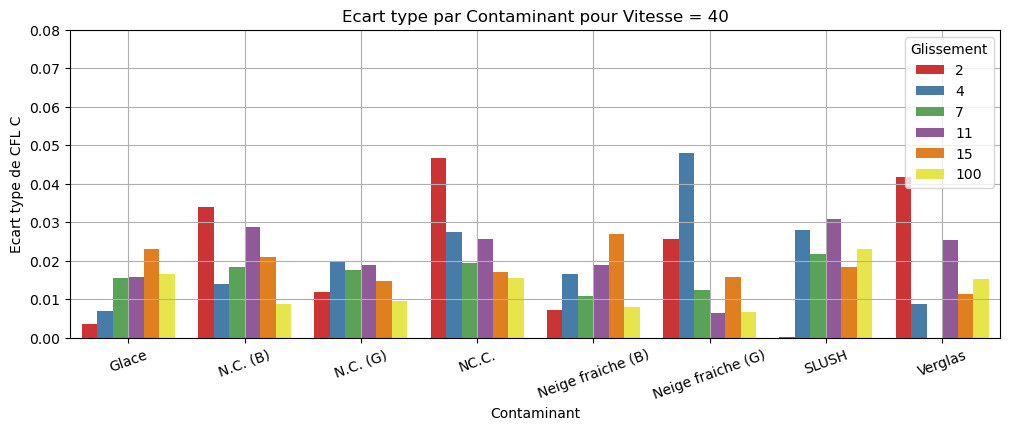

In [101]:
repeta(40)

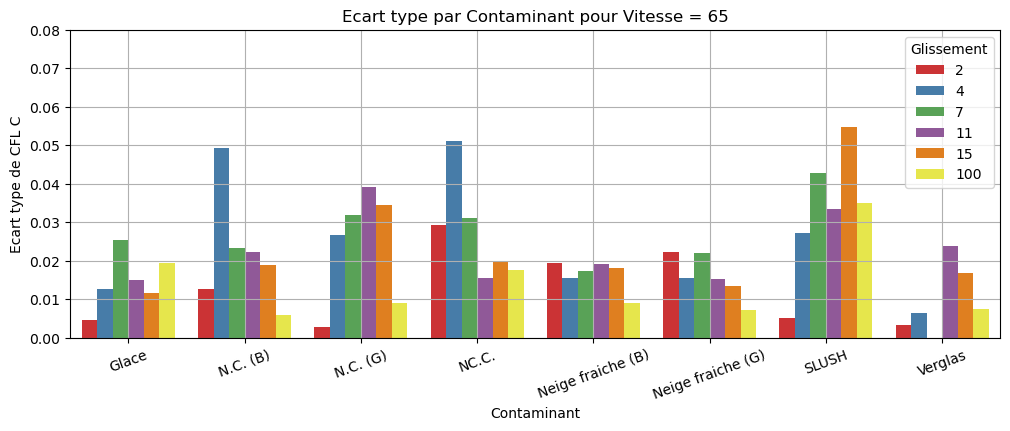

In [102]:
repeta(65)

In [103]:
df_grouped_rp = df_valide.groupby(['Contaminant', 'Vitesse', 'Glissement'])['Moyenne CFL C'].agg(
        mean=np.mean,
        std=np.std,
    ).fillna(0)
df_grouped_rp['Seuil'] = df_grouped_rp['mean'].apply(seuil)
df_grouped_rp.loc[df_grouped_rp['std']> df_grouped_rp['Seuil']].shape

(26, 3)

## Verglas

In [104]:
#Verglas 	40 	2 	

In [105]:
df_valide[(df_valide["Contaminant"] == "Verglas") & (df_valide["Vitesse"] == 40) & (df_valide["Glissement"] == 2)].sort_values("Moyenne CFL C")

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1624,40,2024-01-18,12:10:14,2,0.006667,0.970476,1.151423,0.537074,0.001111,Verglas,0.0,Valide
1625,40,2024-01-18,12:10:14,2,0.007810,0.864762,0.301573,0.140667,0.000928,Verglas,0.0,Valide
1627,40,2024-01-18,12:10:14,2,0.011800,0.708500,0.358803,0.167362,0.001673,Verglas,0.0,Valide
1628,40,2024-01-18,12:10:14,2,0.015190,0.602381,0.367068,0.171217,0.002502,Verglas,0.0,Valide
1582,40,2024-01-18,12:13:07,2,0.064810,2.367143,1.241262,0.578979,0.005307,Verglas,0.0,Valide
1586,40,2024-01-18,12:13:07,2,0.088143,1.850476,0.824005,0.384352,0.008650,Verglas,0.0,Valide
1584,40,2024-01-18,12:13:07,2,0.093524,2.085714,0.472923,0.220592,0.004729,Verglas,0.0,Valide
1585,40,2024-01-18,12:13:07,2,0.098571,1.988571,0.641274,0.299118,0.006764,Verglas,0.0,Valide


In [106]:
l+=[]
ll+=[1624, 1625, 1627, 1628]
print(len(l), len(ll))

23 52


On supprime 1624, 1625, 1627, 1628

In [107]:
#Verglas 	40 	100

In [108]:
df_valide[(df_valide["Contaminant"] == "Verglas") & (df_valide["Vitesse"] == 40) & (df_valide["Glissement"] == 100)].sort_values("Moyenne CFL C")

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1619,40,2024-01-18,12:33:39,100,0.102095,99.641905,0.170165,0.079372,0.019349,Verglas,0.0,Valide
1617,40,2024-01-18,12:33:39,100,0.107190,99.642381,0.246148,0.114814,0.019083,Verglas,0.0,Valide
1621,40,2024-01-18,12:33:39,100,0.122333,99.123810,0.476576,0.222296,0.016767,Verglas,0.0,Valide
1620,40,2024-01-18,12:33:39,100,0.125619,99.257143,0.478374,0.223134,0.013249,Verglas,0.0,Valide
1660,40,2024-01-18,12:31:46,100,0.131190,99.049524,0.380598,0.177528,0.032149,Verglas,0.0,Valide
1618,40,2024-01-18,12:33:39,100,0.134286,97.978571,1.576468,0.735334,0.053631,Verglas,0.0,Valide
1659,40,2024-01-18,12:31:46,100,0.136333,96.631905,2.735764,1.276080,0.070134,Verglas,0.0,Valide
1662,40,2024-01-18,12:31:46,100,0.142190,97.472381,1.844326,0.860274,0.057992,Verglas,0.0,Valide
1663,40,2024-01-18,12:31:46,100,0.146238,97.750476,1.807926,0.843296,0.050044,Verglas,0.0,Valide
1661,40,2024-01-18,12:31:46,100,0.147190,98.229524,0.683721,0.318918,0.023289,Verglas,0.0,Valide


In [109]:
l+=[1619, 1617]
ll+=[1619, 1617]

## Neige fraiche (B)

In [110]:
df_valide[(df_valide["Contaminant"] == "Neige fraiche (B)") & (df_valide["Vitesse"] == 40) & (df_valide["Moyenne G% [%]"] < 16) & (df_valide["Moyenne G% [%]"] > 10)].sort_values("Moyenne CFL C")

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
114,40,2024-01-16,17:13:45,15,0.122370,14.897407,2.309027,1.077031,0.017156,Neige fraiche (B),28.97,Valide
76,40,2024-01-16,17:08:10,11,0.126083,10.440000,2.669007,1.244942,0.032780,Neige fraiche (B),28.97,Valide
115,40,2024-01-16,17:13:45,15,0.149476,15.244286,2.571396,1.199412,0.039432,Neige fraiche (B),28.97,Valide
116,40,2024-01-16,17:13:45,15,0.162429,15.667143,1.918500,0.894872,0.044124,Neige fraiche (B),28.97,Valide
101,40,2024-01-16,17:08:10,11,0.163952,11.266190,2.866068,1.336860,0.025887,Neige fraiche (B),28.97,Valide
103,40,2024-01-16,17:08:10,11,0.166810,11.511429,2.310152,1.077556,0.026400,Neige fraiche (B),28.97,Valide
138,40,2024-01-16,17:13:45,15,0.169762,15.463333,2.863479,1.335652,0.025789,Neige fraiche (B),28.97,Valide
135,40,2024-01-16,17:13:45,15,0.169952,14.693810,2.737074,1.276691,0.028940,Neige fraiche (B),28.97,Valide
104,40,2024-01-16,17:08:10,11,0.170143,10.632381,2.505883,1.168853,0.027443,Neige fraiche (B),28.97,Valide
100,40,2024-01-16,17:08:10,11,0.170952,10.988095,2.210823,1.031224,0.035391,Neige fraiche (B),28.97,Valide


In [111]:
#Neige fraiche (B) 	65 	100

In [112]:
df_valide[(df_valide["Contaminant"] == "Neige fraiche (B)") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 100)].sort_values("Moyenne CFL C")

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
380,65,2024-01-16,17:19:09,100,0.122138,99.623448,0.329396,0.153645,0.019244,Neige fraiche (B),28.97,Valide
382,65,2024-01-16,17:19:09,100,0.132381,99.830000,0.084143,0.039248,0.007928,Neige fraiche (B),28.97,Valide
384,65,2024-01-16,17:19:09,100,0.133048,99.582857,0.369123,0.172175,0.023555,Neige fraiche (B),28.97,Valide
383,65,2024-01-16,17:19:09,100,0.136571,99.829048,0.117809,0.054951,0.012077,Neige fraiche (B),28.97,Valide
387,65,2024-01-16,17:19:09,100,0.138333,99.931905,0.004024,0.001877,0.007983,Neige fraiche (B),28.97,Valide
409,65,2024-01-16,17:19:09,100,0.138857,99.551429,0.330126,0.153985,0.024253,Neige fraiche (B),28.97,Valide
385,65,2024-01-16,17:19:09,100,0.139238,99.894762,0.024211,0.011293,0.011449,Neige fraiche (B),28.97,Valide
388,65,2024-01-16,17:19:09,100,0.141571,99.731429,0.136282,0.063568,0.007494,Neige fraiche (B),28.97,Valide
386,65,2024-01-16,17:19:09,100,0.143143,99.900476,0.018568,0.008661,0.011774,Neige fraiche (B),28.97,Valide
408,65,2024-01-16,17:19:09,100,0.144810,99.110952,0.563133,0.262670,0.037233,Neige fraiche (B),28.97,Valide


In [113]:
l+=[400, 380,327,76,114]
ll+=[400, 380,327,76,114]


## Neige fraiche (G)

In [114]:
#Neige fraiche (G) 	40 	2

In [115]:
df_valide[(df_valide["Contaminant"] == "Neige fraiche (G)") & (df_valide["Vitesse"] == 40) & (df_valide["Glissement"] == 2)].sort_values("Moyenne CFL C")

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
37,40,2024-01-16,16:57:12,2,0.022619,0.798095,0.847122,0.395135,0.002519,Neige fraiche (G),28.97,Valide
33,40,2024-01-16,16:57:12,2,0.036667,1.611905,0.645404,0.301045,0.002834,Neige fraiche (G),28.97,Valide
32,40,2024-01-16,16:57:12,2,0.044476,0.893810,0.520812,0.242929,0.004854,Neige fraiche (G),28.97,Valide
31,40,2024-01-16,16:57:12,2,0.065857,0.800952,0.487103,0.227206,0.008662,Neige fraiche (G),28.97,Valide
16,40,2024-01-16,16:57:12,2,0.087762,1.739048,0.611775,0.285359,0.005243,Neige fraiche (G),28.97,Valide


In [116]:
l+=[]
ll+=[32]
print(len(l), len(ll))

30 60


On supprime 32

In [117]:
#Neige fraiche (G) 	65 	2

In [118]:
df_valide[(df_valide["Contaminant"] == "Neige fraiche (G)") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 2)].sort_values("Moyenne CFL C")

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
208,65,2024-01-16,16:39:58,2,0.033571,1.209524,0.503334,0.234777,0.003472,Neige fraiche (G),28.97,Valide
207,65,2024-01-16,16:39:58,2,0.034190,1.268095,0.428528,0.199884,0.002542,Neige fraiche (G),28.97,Valide
206,65,2024-01-16,16:39:58,2,0.034905,0.913333,0.289229,0.134909,0.003700,Neige fraiche (G),28.97,Valide
205,65,2024-01-16,16:39:58,2,0.035667,0.687143,0.546883,0.255090,0.004397,Neige fraiche (G),28.97,Valide
204,65,2024-01-16,16:39:58,2,0.036000,1.026500,0.722643,0.337072,0.005272,Neige fraiche (G),28.97,Valide
222,65,2024-01-16,16:39:58,2,0.042000,0.707143,0.612586,0.285737,0.004135,Neige fraiche (G),28.97,Valide
223,65,2024-01-16,16:39:58,2,0.042190,1.204762,0.700761,0.326866,0.005400,Neige fraiche (G),28.97,Valide
453,65,2024-01-16,17:38:50,2,0.054333,1.289048,0.652341,0.304280,0.006468,Neige fraiche (G),28.97,Valide
449,65,2024-01-16,17:38:50,2,0.064286,1.453810,0.605190,0.282287,0.011032,Neige fraiche (G),28.97,Valide
429,65,2024-01-16,17:38:50,2,0.078250,1.940500,0.808894,0.377304,0.010047,Neige fraiche (G),28.97,Valide


In [119]:
l+=[]
ll+=[204, 205,206,207,208, 434, 435]
print(len(l), len(ll))

30 67


On supprime 204, 205,206,207,208, 434, 435

## NCB

In [120]:
# NCB 40 2

In [121]:
df_valide[(df_valide["Contaminant"] == "N.C. (B)") & (df_valide["Vitesse"] == 40) & (df_valide["Glissement"] == 2)].sort_values("Moyenne CFL C")

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
686,40,2024-01-17,16:31:01,2,0.018095,0.643333,0.171211,0.079860,0.000889,N.C. (B),15.75,Valide
687,40,2024-01-17,16:31:01,2,0.019000,1.124286,0.271543,0.126660,0.000949,N.C. (B),15.75,Valide
691,40,2024-01-17,16:31:01,2,0.019238,1.035238,0.244635,0.114108,0.000889,N.C. (B),15.75,Valide
615,40,2024-01-17,14:44:15,2,0.046810,0.961905,0.480475,0.224115,0.002839,N.C. (B),15.75,Valide
616,40,2024-01-17,14:44:15,2,0.052190,1.100000,0.323666,0.150972,0.002857,N.C. (B),15.75,Valide
617,40,2024-01-17,14:44:15,2,0.058667,1.486667,0.447139,0.208565,0.003246,N.C. (B),15.75,Valide
618,40,2024-01-17,14:44:15,2,0.062048,1.654762,0.496967,0.231807,0.003294,N.C. (B),15.75,Valide
672,40,2024-01-17,16:27:31,2,0.070333,0.794762,0.185057,0.086319,0.009536,N.C. (B),15.75,Valide
619,40,2024-01-17,14:44:15,2,0.074524,0.991429,0.221772,0.103444,0.007319,N.C. (B),15.75,Valide
659,40,2024-01-17,16:22:36,2,0.081667,1.231429,0.314106,0.146513,0.008363,N.C. (B),15.75,Valide


In [122]:
l+=[672,617, 687,691,967]
ll+=[615,616,617, 618, 621,672, 674, 686, 687, 691,619, 662, 967]
print(len(l), len(ll))

35 80


on supprime les valeurs 616, 618, 621, 674, 686, 687, 691 qui sont des valeurs abérrantes

In [123]:
# NCB 65 4

In [124]:
df_valide[(df_valide["Contaminant"] == "N.C. (B)") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 4)].sort_values("Moyenne CFL C")

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
840,65,2024-01-17,15:19:04,4,0.053095,1.550476,0.360797,0.168292,0.003576,N.C. (B),15.75,Valide
872,65,2024-01-17,15:24:42,4,0.062381,3.385238,1.100884,0.513501,0.004236,N.C. (B),15.75,Valide
843,65,2024-01-17,15:19:04,4,0.068524,3.575714,0.760037,0.354514,0.004996,N.C. (B),15.75,Valide
869,65,2024-01-17,15:24:42,4,0.099333,4.741429,1.374585,0.641166,0.008416,N.C. (B),15.75,Valide
859,65,2024-01-17,15:22:02,4,0.137762,3.383810,0.712843,0.332501,0.011941,N.C. (B),15.75,Valide
855,65,2024-01-17,15:22:02,4,0.141857,4.725714,1.290909,0.602136,0.012713,N.C. (B),15.75,Valide
854,65,2024-01-17,15:22:02,4,0.184143,5.172381,1.238341,0.577617,0.033936,N.C. (B),15.75,Valide


In [125]:
l+=[840, 843, 872]
ll+=[ 840, 843, 872]
print(len(l), len(ll))

38 83


Les valeurs 840, 843, 872 sont abérrantes

## NCG

In [126]:
## NCG 65   15

In [127]:
df_valide[(df_valide["Contaminant"] == "N.C. (G)") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 15)].sort_values("Moyenne CFL C")

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
988,65,2024-01-17,16:04:50,15,0.094571,18.779524,2.666285,1.243672,0.039730,N.C. (G),15.83,Valide
960,65,2024-01-17,15:55:27,15,0.107810,15.666667,2.301190,1.073376,0.018954,N.C. (G),15.83,Valide
961,65,2024-01-17,15:55:27,15,0.117571,14.822381,2.541462,1.185449,0.016786,N.C. (G),15.83,Valide
962,65,2024-01-17,15:55:27,15,0.123762,14.845714,3.038856,1.417455,0.023761,N.C. (G),15.83,Valide
992,65,2024-01-17,16:04:50,15,0.124952,15.373333,1.655564,0.772228,0.021056,N.C. (G),15.83,Valide
976,65,2024-01-17,16:02:05,15,0.132333,15.992381,2.722374,1.269834,0.027567,N.C. (G),15.83,Valide
959,65,2024-01-17,15:55:27,15,0.150500,15.753000,2.803059,1.307469,0.032930,N.C. (G),15.83,Valide
987,65,2024-01-17,16:04:50,15,0.166800,15.676500,1.687125,0.786949,0.018526,N.C. (G),15.83,Valide
963,65,2024-01-17,15:55:27,15,0.180571,13.577619,2.868264,1.337884,0.045872,N.C. (G),15.83,Valide
973,65,2024-01-17,16:02:05,15,0.180714,14.552857,2.360151,1.100878,0.025836,N.C. (G),15.83,Valide


In [128]:
l+=[976, 959, 988, 986, 960, 961, 962, 992,976, 724]
ll+=[976,959, 988, 986, 960, 961, 962, 992,976, 724]

In [129]:
## NCG 65   4

In [130]:
df_valide[(df_valide["Contaminant"] == "N.C. (G)") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 4)].sort_values("Moyenne CFL C")

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
837,65,2024-01-17,15:19:04,4,0.053905,5.521429,1.887393,0.880363,0.008012,N.C. (G),15.83,Valide
850,65,2024-01-17,15:22:02,4,0.056619,4.202857,1.789956,0.834914,0.007486,N.C. (G),15.83,Valide
835,65,2024-01-17,15:19:04,4,0.057190,3.021905,1.916600,0.893986,0.006013,N.C. (G),15.83,Valide
846,65,2024-01-17,15:22:02,4,0.077600,3.860000,1.547552,0.721846,0.008419,N.C. (G),15.83,Valide
847,65,2024-01-17,15:22:02,4,0.090810,3.214286,0.875811,0.408517,0.006608,N.C. (G),15.83,Valide
860,65,2024-01-17,15:24:42,4,0.104100,3.700000,1.071757,0.499914,0.009840,N.C. (G),15.83,Valide
861,65,2024-01-17,15:24:42,4,0.105524,4.176190,0.967711,0.451383,0.008091,N.C. (G),15.83,Valide
832,65,2024-01-17,15:19:04,4,0.125150,3.692000,1.384932,0.645993,0.017491,N.C. (G),15.83,Valide


In [131]:
l+=[835,837, 850]
ll+=[835,837, 850]
print(len(l), len(ll))

51 96


On supprime 837, 850

## NCC

In [132]:
## NCC 40 2

In [133]:
df_valide[(df_valide["Contaminant"] == "NC.C.") & (df_valide["Vitesse"] == 40) & (df_valide["Glissement"] == 2)].sort_values("Moyenne CFL C")

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1191,40,2024-01-18,17:02:43,2,0.011667,0.171429,0.339872,0.158531,0.001826,NC.C.,12.13,Valide
1190,40,2024-01-18,17:02:43,2,0.017238,0.531905,0.353534,0.164904,0.002663,NC.C.,12.13,Valide
1133,40,2024-01-18,17:29:14,2,0.025350,0.634000,0.311776,0.145426,0.003528,NC.C.,12.13,Valide
1189,40,2024-01-18,17:02:43,2,0.027905,0.432857,0.574057,0.267765,0.005059,NC.C.,12.13,Valide
1188,40,2024-01-18,17:02:43,2,0.040952,1.079524,0.549932,0.256512,0.005536,NC.C.,12.13,Valide
1135,40,2024-01-18,17:29:14,2,0.055000,0.748095,0.426012,0.198711,0.009731,NC.C.,12.13,Valide
1187,40,2024-01-18,17:02:43,2,0.056571,1.151429,0.484523,0.226003,0.008213,NC.C.,12.13,Valide
1044,40,2024-01-18,17:00:42,2,0.067143,1.553333,0.815753,0.380503,0.010046,NC.C.,12.13,Valide
1142,40,2024-01-18,17:29:14,2,0.067286,1.134286,0.472425,0.220360,0.010517,NC.C.,12.13,Valide
1136,40,2024-01-18,17:29:14,2,0.083333,1.071905,0.630425,0.294058,0.014499,NC.C.,12.13,Valide


In [134]:
l+=[1135, 1181]
ll+=[1135, 1181]
print(len(l), len(ll))

53 98


On supprime 1135, 1181

In [135]:
## NCC 40 100

In [136]:
df_valide[(df_valide["Contaminant"] == "NC.C.") & (df_valide["Vitesse"] == 40) & (df_valide["Glissement"] == 100)].sort_values("Moyenne CFL C")

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1300,40,2024-01-18,17:41:12,100,0.137476,99.157619,0.566753,0.264358,0.018179,NC.C.,12.13,Valide
1255,40,2024-01-18,17:26:46,100,0.137952,99.433810,0.386037,0.180065,0.008663,NC.C.,12.13,Valide
1122,40,2024-01-18,17:24:23,100,0.140714,99.336190,0.447990,0.208962,0.010937,NC.C.,12.13,Valide
1301,40,2024-01-18,17:41:12,100,0.141667,98.889048,0.862061,0.402103,0.041811,NC.C.,12.13,Valide
1257,40,2024-01-18,17:26:46,100,0.142667,99.283333,0.351117,0.163776,0.013854,NC.C.,12.13,Valide
1253,40,2024-01-18,17:26:46,100,0.144619,98.685238,0.719768,0.335731,0.032171,NC.C.,12.13,Valide
1256,40,2024-01-18,17:26:46,100,0.145524,98.837619,0.662064,0.308816,0.014682,NC.C.,12.13,Valide
1302,40,2024-01-18,17:41:12,100,0.147333,99.091905,0.603942,0.281705,0.017611,NC.C.,12.13,Valide
1121,40,2024-01-18,17:24:23,100,0.147810,99.462381,0.284779,0.132833,0.013094,NC.C.,12.13,Valide
1303,40,2024-01-18,17:41:12,100,0.147952,99.026667,0.733862,0.342305,0.019577,NC.C.,12.13,Valide


In [137]:
l+=[1305, 1304, 1306]
ll+=[1305, 1304, 1306]

In [138]:
## NCC 65 2

In [139]:
df_valide[(df_valide["Contaminant"] == "NC.C.") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 2)].sort_values("Moyenne CFL C")

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1403,65,2024-01-18,16:48:50,2,0.034571,0.948571,0.463684,0.216283,0.005372,NC.C.,12.13,Valide
1405,65,2024-01-18,16:48:50,2,0.044381,0.796190,0.519321,0.242234,0.005705,NC.C.,12.13,Valide
1325,65,2024-01-18,16:23:04,2,0.061667,2.376667,0.542359,0.252980,0.005351,NC.C.,12.13,Valide
1408,65,2024-01-18,16:48:50,2,0.065429,0.905238,0.351790,0.164090,0.010852,NC.C.,12.13,Valide
1409,65,2024-01-18,16:48:50,2,0.078381,1.102857,0.642846,0.299852,0.011079,NC.C.,12.13,Valide
1413,65,2024-01-18,16:48:50,2,0.078429,1.247143,0.478551,0.223217,0.008790,NC.C.,12.13,Valide
1322,65,2024-01-18,16:23:04,2,0.080143,2.002857,0.779238,0.363471,0.011655,NC.C.,12.13,Valide
1315,65,2024-01-18,16:23:04,2,0.088095,1.305714,0.730634,0.340800,0.011619,NC.C.,12.13,Valide
1452,65,2024-01-18,16:25:08,2,0.094714,1.478095,0.585804,0.273245,0.011555,NC.C.,12.13,Valide
1461,65,2024-01-18,16:25:08,2,0.100429,1.054762,0.639864,0.298461,0.013963,NC.C.,12.13,Valide


In [140]:
l+=[1325, 1403, 1460, 1458]
ll+=[1325, 1403, 1460, 1458]
print(len(l), len(ll))

60 105


On supprime  1325, 1403, 1460

In [141]:
## NCC 65 4

In [142]:
df_valide[(df_valide["Contaminant"] == "NC.C.") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 4)].sort_values("Moyenne CFL C")

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1551,65,2024-01-18,16:50:56,4,0.027857,3.408571,0.925620,0.431750,0.002287,NC.C.,12.13,Valide
1549,65,2024-01-18,16:50:56,4,0.030190,1.678571,0.819916,0.382445,0.005437,NC.C.,12.13,Valide
1546,65,2024-01-18,16:50:56,4,0.102000,1.233810,0.438902,0.204723,0.027833,NC.C.,12.13,Valide
1472,65,2024-01-18,16:29:04,4,0.133238,3.881905,1.346661,0.628142,0.016034,NC.C.,12.13,Valide
1330,65,2024-01-18,16:27:33,4,0.150476,3.370952,0.725499,0.338405,0.014112,NC.C.,12.13,Valide
1462,65,2024-01-18,16:29:04,4,0.152286,3.750000,1.179292,0.550073,0.015850,NC.C.,12.13,Valide
1473,65,2024-01-18,16:29:04,4,0.156048,4.913333,1.107309,0.516497,0.020498,NC.C.,12.13,Valide
1331,65,2024-01-18,16:27:33,4,0.163143,3.710952,0.799193,0.372778,0.014090,NC.C.,12.13,Valide
1340,65,2024-01-18,16:27:33,4,0.169190,3.913333,1.557518,0.726495,0.019281,NC.C.,12.13,Valide
1334,65,2024-01-18,16:27:33,4,0.171619,4.500952,1.476929,0.688904,0.027915,NC.C.,12.13,Valide


In [143]:
l+=[1551, 1472, 1473]
ll+=[1472,1473, 1549, 1551]
print(len(l), len(ll))

63 109


On supprime 1472,1473, 1549, 1551

In [144]:
## NCC 65 15

In [145]:
df_valide[(df_valide["Contaminant"] == "NC.C.") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 15)].sort_values("Moyenne CFL C")

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1374,65,2024-01-18,16:40:48,15,0.184667,15.637619,1.738767,0.811037,0.044715,NC.C.,12.13,Valide
1440,65,2024-01-18,16:57:01,15,0.189429,15.280000,1.684918,0.785920,0.034771,NC.C.,12.13,Valide
1383,65,2024-01-18,16:40:48,15,0.198143,15.575714,3.192121,1.488945,0.058075,NC.C.,12.13,Valide
1521,65,2024-01-18,16:43:53,15,0.203286,15.459048,2.278501,1.062793,0.032755,NC.C.,12.13,Valide
1508,65,2024-01-18,16:43:53,15,0.207048,14.934286,1.646486,0.767993,0.039892,NC.C.,12.13,Valide
1509,65,2024-01-18,16:43:53,15,0.210286,14.902857,2.952237,1.377052,0.059993,NC.C.,12.13,Valide
1375,65,2024-01-18,16:40:48,15,0.216095,14.548571,3.203801,1.494393,0.053301,NC.C.,12.13,Valide
1511,65,2024-01-18,16:43:53,15,0.216667,15.543333,1.923687,0.897292,0.036933,NC.C.,12.13,Valide
1373,65,2024-01-18,16:40:48,15,0.222952,14.677619,1.795697,0.837592,0.041273,NC.C.,12.13,Valide
1520,65,2024-01-18,16:43:53,15,0.227857,14.422381,2.235967,1.042953,0.033234,NC.C.,12.13,Valide


In [146]:
l+=[1396, 1574, 1383]
ll+=[1396, 1574, 1383]


In [147]:
## NCC 65 100

In [148]:
df_valide[(df_valide["Contaminant"] == "NC.C.") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 100)].sort_values("Moyenne CFL C")

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1569,65,2024-01-18,16:58:36,100,0.150300,99.376000,0.415444,0.193781,0.028251,NC.C.,12.13,Valide
1526,65,2024-01-18,16:47:09,100,0.161200,99.281500,0.398369,0.185817,0.021170,NC.C.,12.13,Valide
1570,65,2024-01-18,16:58:36,100,0.161429,99.220000,0.431799,0.201410,0.025188,NC.C.,12.13,Valide
1524,65,2024-01-18,16:47:09,100,0.164238,98.871429,0.833710,0.388879,0.053771,NC.C.,12.13,Valide
1568,65,2024-01-18,16:58:36,100,0.165429,99.071905,0.416913,0.194466,0.044138,NC.C.,12.13,Valide
1391,65,2024-01-18,16:45:35,100,0.165952,98.811429,0.729865,0.340441,0.063468,NC.C.,12.13,Valide
1571,65,2024-01-18,16:58:36,100,0.166095,97.719524,1.536615,0.716744,0.107490,NC.C.,12.13,Valide
1527,65,2024-01-18,16:47:09,100,0.168238,98.859048,0.932475,0.434947,0.044034,NC.C.,12.13,Valide
1523,65,2024-01-18,16:47:09,100,0.169429,99.186190,0.381031,0.177730,0.031968,NC.C.,12.13,Valide
1535,65,2024-01-18,16:47:09,100,0.174381,99.225714,0.570785,0.266239,0.027474,NC.C.,12.13,Valide


In [149]:
l+=[1396, 1574]
ll+=[1396, 1574]


## Slush

In [150]:
# Slush 40  4

In [151]:
df_valide[(df_valide["Contaminant"] == "SLUSH") & (df_valide["Vitesse"] == 40) & (df_valide["Glissement"] == 4)].sort_values("Moyenne CFL C")

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1859,40,2024-01-23,15:04:24,4,0.000000,0.233810,0.233591,0.108957,0.001729,SLUSH,15.0,Valide
1860,40,2024-01-23,15:04:24,4,0.000000,0.091905,0.304362,0.141968,0.001700,SLUSH,15.0,Valide
1866,40,2024-01-23,15:05:47,4,0.000000,0.078571,0.226612,0.105702,0.002182,SLUSH,15.0,Valide
1867,40,2024-01-23,15:05:47,4,0.000000,0.091429,0.293671,0.136981,0.001044,SLUSH,15.0,Valide
1865,40,2024-01-23,15:05:47,4,0.008571,0.088571,0.135768,0.063328,0.005662,SLUSH,15.0,Valide
1858,40,2024-01-23,15:04:24,4,0.009714,0.340476,0.426690,0.199027,0.004818,SLUSH,15.0,Valide
1857,40,2024-01-23,15:04:24,4,0.036200,0.703500,0.419728,0.195779,0.014248,SLUSH,15.0,Valide
1864,40,2024-01-23,15:05:47,4,0.042667,0.685238,0.866670,0.404253,0.018159,SLUSH,15.0,Valide
1861,40,2024-01-23,15:05:47,4,0.046000,3.445714,2.543190,1.186255,0.017216,SLUSH,15.0,Valide
1862,40,2024-01-23,15:05:47,4,0.062286,5.056190,2.496501,1.164477,0.016019,SLUSH,15.0,Valide


In [152]:
l+=[]
ll+=[1864,1862,1861, 1863]
print(len(l), len(ll))

68 118


On supprime 1864 ,1862, 1863

In [153]:
# Slush 40  100

In [154]:
df_valide[(df_valide["Contaminant"] == "SLUSH") & (df_valide["Vitesse"] == 40) & (df_valide["Glissement"] == 100)].sort_values("Moyenne CFL C")

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1913,40,2024-01-23,15:15:27,100,0.157095,98.130952,1.783348,0.831831,0.049071,SLUSH,15.0,Valide
1917,40,2024-01-23,15:16:39,100,0.159476,98.184286,1.174796,0.547976,0.051272,SLUSH,15.0,Valide
1916,40,2024-01-23,15:15:27,100,0.161048,98.111905,1.969367,0.918599,0.046092,SLUSH,15.0,Valide
1919,40,2024-01-23,15:16:39,100,0.165810,97.955238,1.922274,0.896633,0.048354,SLUSH,15.0,Valide
1920,40,2024-01-23,15:16:39,100,0.175619,98.068095,1.303755,0.608128,0.046432,SLUSH,15.0,Valide
1914,40,2024-01-23,15:15:27,100,0.178095,98.396190,1.226252,0.571978,0.042263,SLUSH,15.0,Valide
1912,40,2024-01-23,15:15:27,100,0.178714,97.849524,1.670792,0.779330,0.053188,SLUSH,15.0,Valide
1911,40,2024-01-23,15:15:27,100,0.179619,98.497143,1.281227,0.597620,0.044553,SLUSH,15.0,Valide
1915,40,2024-01-23,15:15:27,100,0.182952,98.238571,1.346307,0.627977,0.034702,SLUSH,15.0,Valide
1921,40,2024-01-23,15:16:39,100,0.191286,98.121905,1.102119,0.514077,0.047501,SLUSH,15.0,Valide


In [155]:
l+=[1922,1913,1917]
ll+=[1922,1913,1917]

In [156]:
# Slush 65 7

In [157]:
df_valide[(df_valide["Contaminant"] == "SLUSH") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 7)].sort_values("Moyenne CFL C")

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1962,65,2024-01-23,14:53:38,7,0.051476,7.246190,1.953347,0.911127,0.015858,SLUSH,15.0,Valide
1961,65,2024-01-23,14:53:38,7,0.086143,4.282857,2.821574,1.316106,0.049312,SLUSH,15.0,Valide
1953,65,2024-01-23,14:51:05,7,0.136810,5.070476,2.701408,1.260055,0.048197,SLUSH,15.0,Valide


In [158]:
l+=[]
ll+=[1953]
print(len(l), len(ll))

71 122


On supprime 1953

In [159]:
# Slush 65 11

In [160]:
df_valide[(df_valide["Contaminant"] == "SLUSH") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 11)].sort_values("Moyenne CFL C")

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1973,65,2024-01-23,14:55:57,11,0.018476,3.722857,2.255877,1.052240,0.007639,SLUSH,15.0,Valide
1971,65,2024-01-23,14:54:49,11,0.033476,0.727143,1.019025,0.475318,0.022171,SLUSH,15.0,Valide
1975,65,2024-01-23,14:55:57,11,0.051300,22.601500,8.549194,3.987718,0.058201,SLUSH,15.0,Valide
1976,65,2024-01-23,14:55:57,11,0.096000,11.500000,2.796201,1.304271,0.021469,SLUSH,15.0,Valide


In [161]:
l+=[1975]
ll+=[1976,1975]
print(len(l), len(ll))

72 124


La valeur 1971 sont des valeurs abérrante

In [162]:
# Slush 65 15

In [163]:
df_valide[(df_valide["Contaminant"] == "SLUSH") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 15)].sort_values("Moyenne CFL C")

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1989,65,2024-01-23,14:58:13,15,0.017333,18.996667,2.690467,1.254952,0.007572,SLUSH,15.0,Valide
1981,65,2024-01-23,14:57:04,15,0.023905,21.404286,2.819127,1.314964,0.015697,SLUSH,15.0,Valide
1990,65,2024-01-23,14:58:13,15,0.042714,20.467619,4.757227,2.218979,0.029582,SLUSH,15.0,Valide
1984,65,2024-01-23,14:57:04,15,0.093762,14.119524,2.935044,1.369033,0.029873,SLUSH,15.0,Valide
1992,65,2024-01-23,14:58:13,15,0.105286,17.890000,2.003774,0.934648,0.058167,SLUSH,15.0,Valide
1993,65,2024-01-23,14:58:13,15,0.157714,15.135714,2.958778,1.380103,0.052171,SLUSH,15.0,Valide


In [164]:
l+=[1989, 1981, 1990, 1992]
ll+=[1984, 1989, 1981, 1990, 1992]
print(len(l), len(ll))

76 129


In [165]:
df_valide.columns

Index(['Vitesse', 'Date', 'Heure', 'Glissement', 'Moyenne CFL C',
       'Moyenne G% [%]', 'ET G%', 'Ic G%', 'ET CFLC', 'Contaminant',
       'hauteur (mm)', 'Test_2'],
      dtype='object')

On supprime 1984, 1989, 1981, 1990 	

In [166]:
df_valide[(df_valide["Contaminant"] == "SLUSH") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 15)].sort_values("Moyenne CFL C")

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1989,65,2024-01-23,14:58:13,15,0.017333,18.996667,2.690467,1.254952,0.007572,SLUSH,15.0,Valide
1981,65,2024-01-23,14:57:04,15,0.023905,21.404286,2.819127,1.314964,0.015697,SLUSH,15.0,Valide
1990,65,2024-01-23,14:58:13,15,0.042714,20.467619,4.757227,2.218979,0.029582,SLUSH,15.0,Valide
1984,65,2024-01-23,14:57:04,15,0.093762,14.119524,2.935044,1.369033,0.029873,SLUSH,15.0,Valide
1992,65,2024-01-23,14:58:13,15,0.105286,17.890000,2.003774,0.934648,0.058167,SLUSH,15.0,Valide
1993,65,2024-01-23,14:58:13,15,0.157714,15.135714,2.958778,1.380103,0.052171,SLUSH,15.0,Valide


In [167]:
# Slush 65 100

In [168]:
df_valide[(df_valide["Contaminant"] == "SLUSH") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 100)].sort_values("Moyenne CFL C")

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
2003,65,2024-01-23,15:00:27,100,0.092286,98.902381,0.489090,0.228133,0.052111,SLUSH,15.0,Valide
2004,65,2024-01-23,15:00:27,100,0.098905,99.050952,0.388277,0.181109,0.048468,SLUSH,15.0,Valide
2002,65,2024-01-23,15:00:27,100,0.112190,99.092857,0.673269,0.314042,0.042328,SLUSH,15.0,Valide
2005,65,2024-01-23,15:00:27,100,0.117150,98.579500,1.090647,0.508725,0.065427,SLUSH,15.0,Valide
2000,65,2024-01-23,14:59:21,100,0.122238,99.002381,0.406570,0.189642,0.038412,SLUSH,15.0,Valide
2007,65,2024-01-23,15:00:27,100,0.140095,99.014762,0.563131,0.262669,0.038104,SLUSH,15.0,Valide
1998,65,2024-01-23,14:59:21,100,0.144905,98.073810,1.750553,0.816534,0.095123,SLUSH,15.0,Valide
1997,65,2024-01-23,14:59:21,100,0.166333,98.930476,0.609881,0.284475,0.070645,SLUSH,15.0,Valide
1994,65,2024-01-23,14:59:21,100,0.186286,98.707143,0.638037,0.297608,0.064095,SLUSH,15.0,Valide
1995,65,2024-01-23,14:59:21,100,0.192381,97.633810,1.750253,0.816395,0.097214,SLUSH,15.0,Valide


In [169]:
l+=[1997, 1994, 1995,2003,2004]
ll+=[1997, 1994, 1995,2003,2004]
print(len(l), len(ll))

81 134


On supprime 1998, 1997, 1994, 1995

In [170]:
l+=[1755, 1756, 1759, 2030, 1779, 1832, 1827, 1824]
ll+=[1755, 1756, 1759, 2030, 1779, 1832, 1827, 1824]

## Glace

In [171]:
df_valide[(df_valide["Contaminant"] == "Glace") & (df_valide["Vitesse"] == 40) & (df_valide["Glissement"] == 2)].sort_values("Moyenne CFL C")

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1755,40,2024-01-19,12:07:52,2,0.000000,2.621429,0.830923,0.387579,0.000561,Glace,0.0,Valide
1756,40,2024-01-19,12:07:52,2,0.000000,2.414762,0.821533,0.383199,0.000436,Glace,0.0,Valide
1759,40,2024-01-19,12:07:52,2,0.000000,6.719048,1.025104,0.478154,0.000561,Glace,0.0,Valide
1754,40,2024-01-19,12:04:37,2,0.005143,2.594286,0.594824,0.277452,0.000478,Glace,0.0,Valide
1753,40,2024-01-19,12:04:37,2,0.006238,2.582857,0.393448,0.183521,0.000539,Glace,0.0,Valide
2008,40,2024-01-19,12:06:18,2,0.006476,2.024762,0.573163,0.267348,0.000512,Glace,0.0,Valide
2009,40,2024-01-19,12:06:18,2,0.006700,2.538000,0.679594,0.316993,0.000865,Glace,0.0,Valide
1752,40,2024-01-19,12:04:37,2,0.007400,2.886000,0.615462,0.287079,0.000754,Glace,0.0,Valide
2010,40,2024-01-19,12:06:18,2,0.007429,2.581429,1.037286,0.483836,0.000598,Glace,0.0,Valide
1751,40,2024-01-19,12:04:37,2,0.009000,2.291429,0.708529,0.330489,0.000837,Glace,0.0,Valide


In [172]:
## Glace 40 15 

In [173]:
df_valide[(df_valide["Contaminant"] == "Glace") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 11)].sort_values("Moyenne CFL C")

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1824,65,2024-01-19,11:49:39,11,0.064476,10.221905,2.292587,1.069363,0.013299,Glace,0.0,Valide
1820,65,2024-01-19,11:49:39,11,0.081905,11.078571,2.041459,0.952226,0.013953,Glace,0.0,Valide
1821,65,2024-01-19,11:49:39,11,0.088100,11.670000,2.518554,1.174764,0.017973,Glace,0.0,Valide
2076,65,2024-01-19,11:48:20,11,0.093600,11.895000,1.684526,0.785736,0.017572,Glace,0.0,Valide
2081,65,2024-01-19,11:51:20,11,0.094667,12.311905,1.425176,0.664764,0.018345,Glace,0.0,Valide
2074,65,2024-01-19,11:48:20,11,0.097000,11.962381,2.927299,1.365420,0.025211,Glace,0.0,Valide
2075,65,2024-01-19,11:48:20,11,0.098000,10.333333,1.568708,0.731714,0.012369,Glace,0.0,Valide
2080,65,2024-01-19,11:51:20,11,0.105050,9.726000,0.435387,0.203084,0.015237,Glace,0.0,Valide
2082,65,2024-01-19,11:51:20,11,0.108095,10.180952,1.808380,0.843508,0.020859,Glace,0.0,Valide
2077,65,2024-01-19,11:48:20,11,0.120190,10.675714,1.399141,0.652621,0.017784,Glace,0.0,Valide


In [174]:
l+=[1780, 1785,2040, 2041, 2042]
ll+=[1780, 1785,2040, 2041, 2042]
print(len(l), len(ll))

94 147


On supprime 1780, 1785, 2041, 2042

In [175]:
## Glace 40 100

In [176]:
df_valide[(df_valide["Contaminant"] == "Glace") & (df_valide["Vitesse"] == 40) & (df_valide["Glissement"] == 100)].sort_values("Moyenne CFL C")

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
2051,40,2024-01-19,12:36:27,100,0.056429,99.811429,0.145371,0.067808,0.007514,Glace,0.0,Valide
2052,40,2024-01-19,12:36:27,100,0.058476,99.721429,0.199180,0.092906,0.009511,Glace,0.0,Valide
2045,40,2024-01-19,12:32:48,100,0.058952,99.862857,0.032580,0.015197,0.006360,Glace,0.0,Valide
2050,40,2024-01-19,12:36:27,100,0.059571,99.872381,0.027369,0.012766,0.008942,Glace,0.0,Valide
2046,40,2024-01-19,12:32:48,100,0.061286,99.797143,0.106777,0.049806,0.006724,Glace,0.0,Valide
2047,40,2024-01-19,12:32:48,100,0.063381,99.567143,0.165775,0.077325,0.011859,Glace,0.0,Valide
1794,40,2024-01-19,12:34:26,100,0.064095,99.580952,0.198668,0.092668,0.009203,Glace,0.0,Valide
1793,40,2024-01-19,12:34:26,100,0.065619,99.793810,0.105284,0.049109,0.006469,Glace,0.0,Valide
1792,40,2024-01-19,12:34:26,100,0.067333,99.373333,0.422698,0.197165,0.009068,Glace,0.0,Valide
2049,40,2024-01-19,12:36:27,100,0.068100,99.519500,0.538462,0.251162,0.013298,Glace,0.0,Valide


In [177]:
l+=[1790, 2048, 2043, 1791]
ll+=[1790, 2048, 2043, 1791]

In [178]:
# Glace 65 7

In [179]:
df_valide[(df_valide["Contaminant"] == "Glace") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 7)]

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1810,65,2024-01-19,11:44:13,7,0.043550,4.380000,0.820943,0.382924,0.004383,Glace,0.0,Valide
1815,65,2024-01-19,11:47:06,7,0.059857,6.948095,1.270487,0.592611,0.008828,Glace,0.0,Valide
2068,65,2024-01-19,11:45:24,7,0.076667,4.478095,1.285331,0.599535,0.013466,Glace,0.0,Valide
2071,65,2024-01-19,11:45:24,7,0.088619,7.612381,1.010955,0.471553,0.015230,Glace,0.0,Valide
2072,65,2024-01-19,11:45:24,7,0.109619,7.560000,0.779936,0.363796,0.016296,Glace,0.0,Valide


In [180]:
l+=[1815, 2068]
ll+=[1810, 1815, 2068]
print(len(l), len(ll))

100 154


On supprime 1815, 1810, 2068

In [181]:
## Glace 65 100
df_valide[(df_valide["Contaminant"] == "Glace") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 100)].sort_values("Moyenne CFL C")

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1838,65,2024-01-19,11:58:22,100,0.052190,99.812381,0.138452,0.064580,0.008477,Glace,0.0,Valide
2091,65,2024-01-19,11:57:10,100,0.055000,99.880000,0.046566,0.021721,0.008742,Glace,0.0,Valide
2090,65,2024-01-19,11:57:10,100,0.056619,99.897143,0.024113,0.011247,0.004421,Glace,0.0,Valide
1837,65,2024-01-19,11:58:22,100,0.057714,99.738095,0.163420,0.076226,0.011950,Glace,0.0,Valide
2089,65,2024-01-19,11:57:10,100,0.057905,99.864762,0.064701,0.030179,0.011623,Glace,0.0,Valide
2096,65,2024-01-19,12:02:08,100,0.062200,99.703500,0.127662,0.059547,0.011723,Glace,0.0,Valide
1839,65,2024-01-19,11:58:22,100,0.063571,99.660952,0.346264,0.161513,0.013381,Glace,0.0,Valide
2092,65,2024-01-19,11:57:10,100,0.066143,99.856190,0.085468,0.039866,0.009866,Glace,0.0,Valide
2095,65,2024-01-19,12:02:08,100,0.068571,99.849524,0.112627,0.052534,0.007979,Glace,0.0,Valide
2094,65,2024-01-19,12:02:08,100,0.070238,99.873810,0.077426,0.036115,0.010281,Glace,0.0,Valide


In [182]:
l+=[2093, 1835, 1836,2088, 2097 ]
ll+=[2093, 1835, 1836,2088, 2097 ]

## Dry

In [183]:
#Dry 40 2

In [184]:
df_valide[(df_valide["Contaminant"] == "DRY") & (df_valide["Vitesse"] == 40) & (df_valide["Glissement"] == 2)]

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1588,40,2024-01-18,12:13:07,2,0.232048,0.746667,0.189376,0.088333,0.060155,DRY,0.0,Valide
1629,40,2024-01-18,12:10:14,2,0.170857,0.566667,0.200533,0.093537,0.042651,DRY,0.0,Valide


In [185]:
l+=[]
ll+=[1588]
print(len(l), len(ll))

105 160


On supprime 1588

In [186]:
#Dry 65 4

In [187]:
df_valide[(df_valide["Contaminant"] == "DRY") & (df_valide["Vitesse"] == 65) & (df_valide["Glissement"] == 4)]

,Vitesse,Date,Heure,Glissement,Moyenne CFL C,Moyenne G% [%],ET G%,Ic G%,ET CFLC,Contaminant,hauteur (mm),Test_2
1679,65,2024-01-18,11:49:33,4,0.593952,2.989048,1.238842,0.577850,0.124293,DRY,0.0,Valide
1720,65,2024-01-18,11:47:57,4,0.341000,1.154286,0.557840,0.260201,0.123241,DRY,0.0,Valide


In [188]:
l+=[]
ll+=[1679]
print(len(l), len(ll))

105 161


On supprime

In [189]:
df_valide=df_valide.drop(ll)


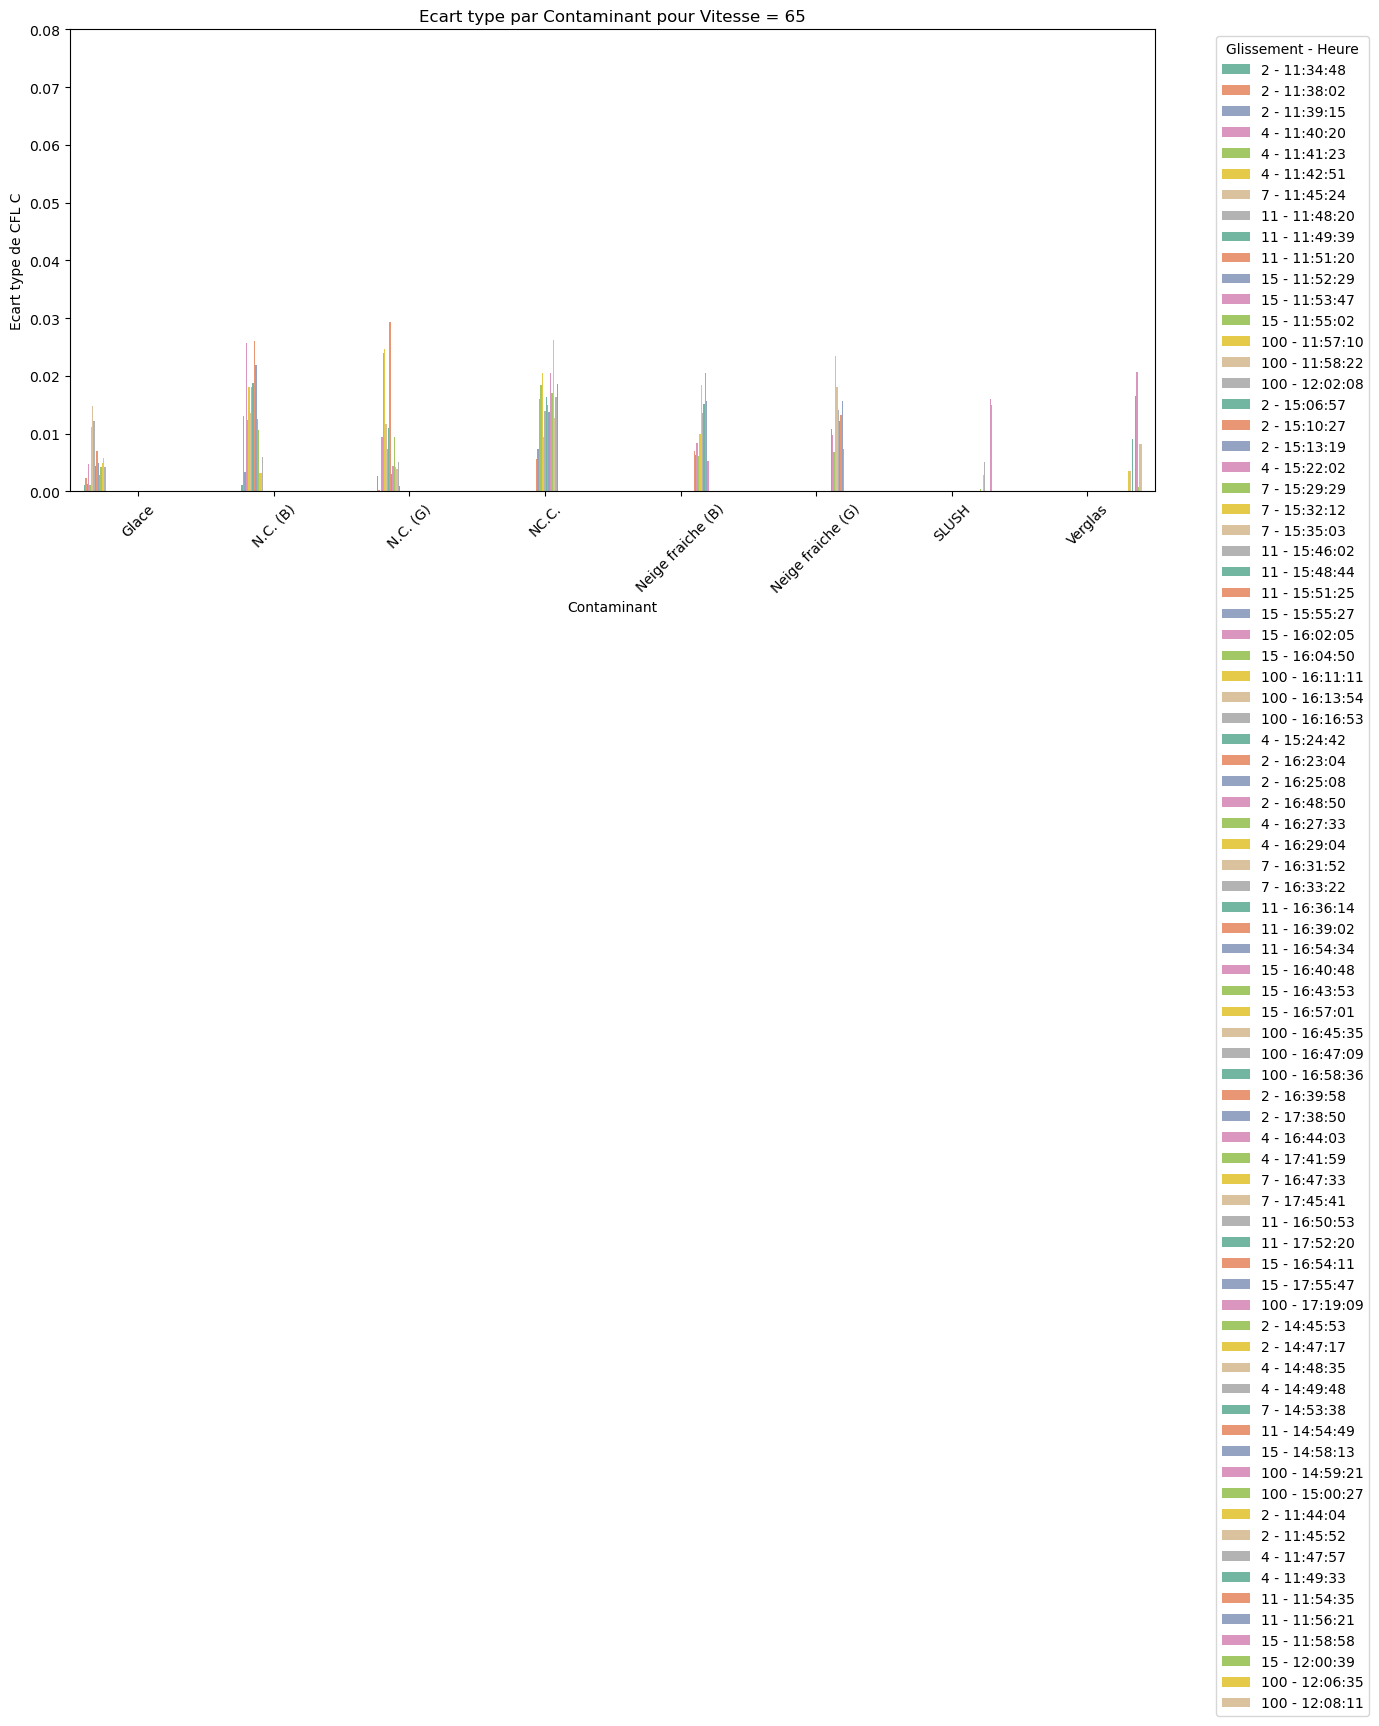

In [190]:
Reproductibilite(65)

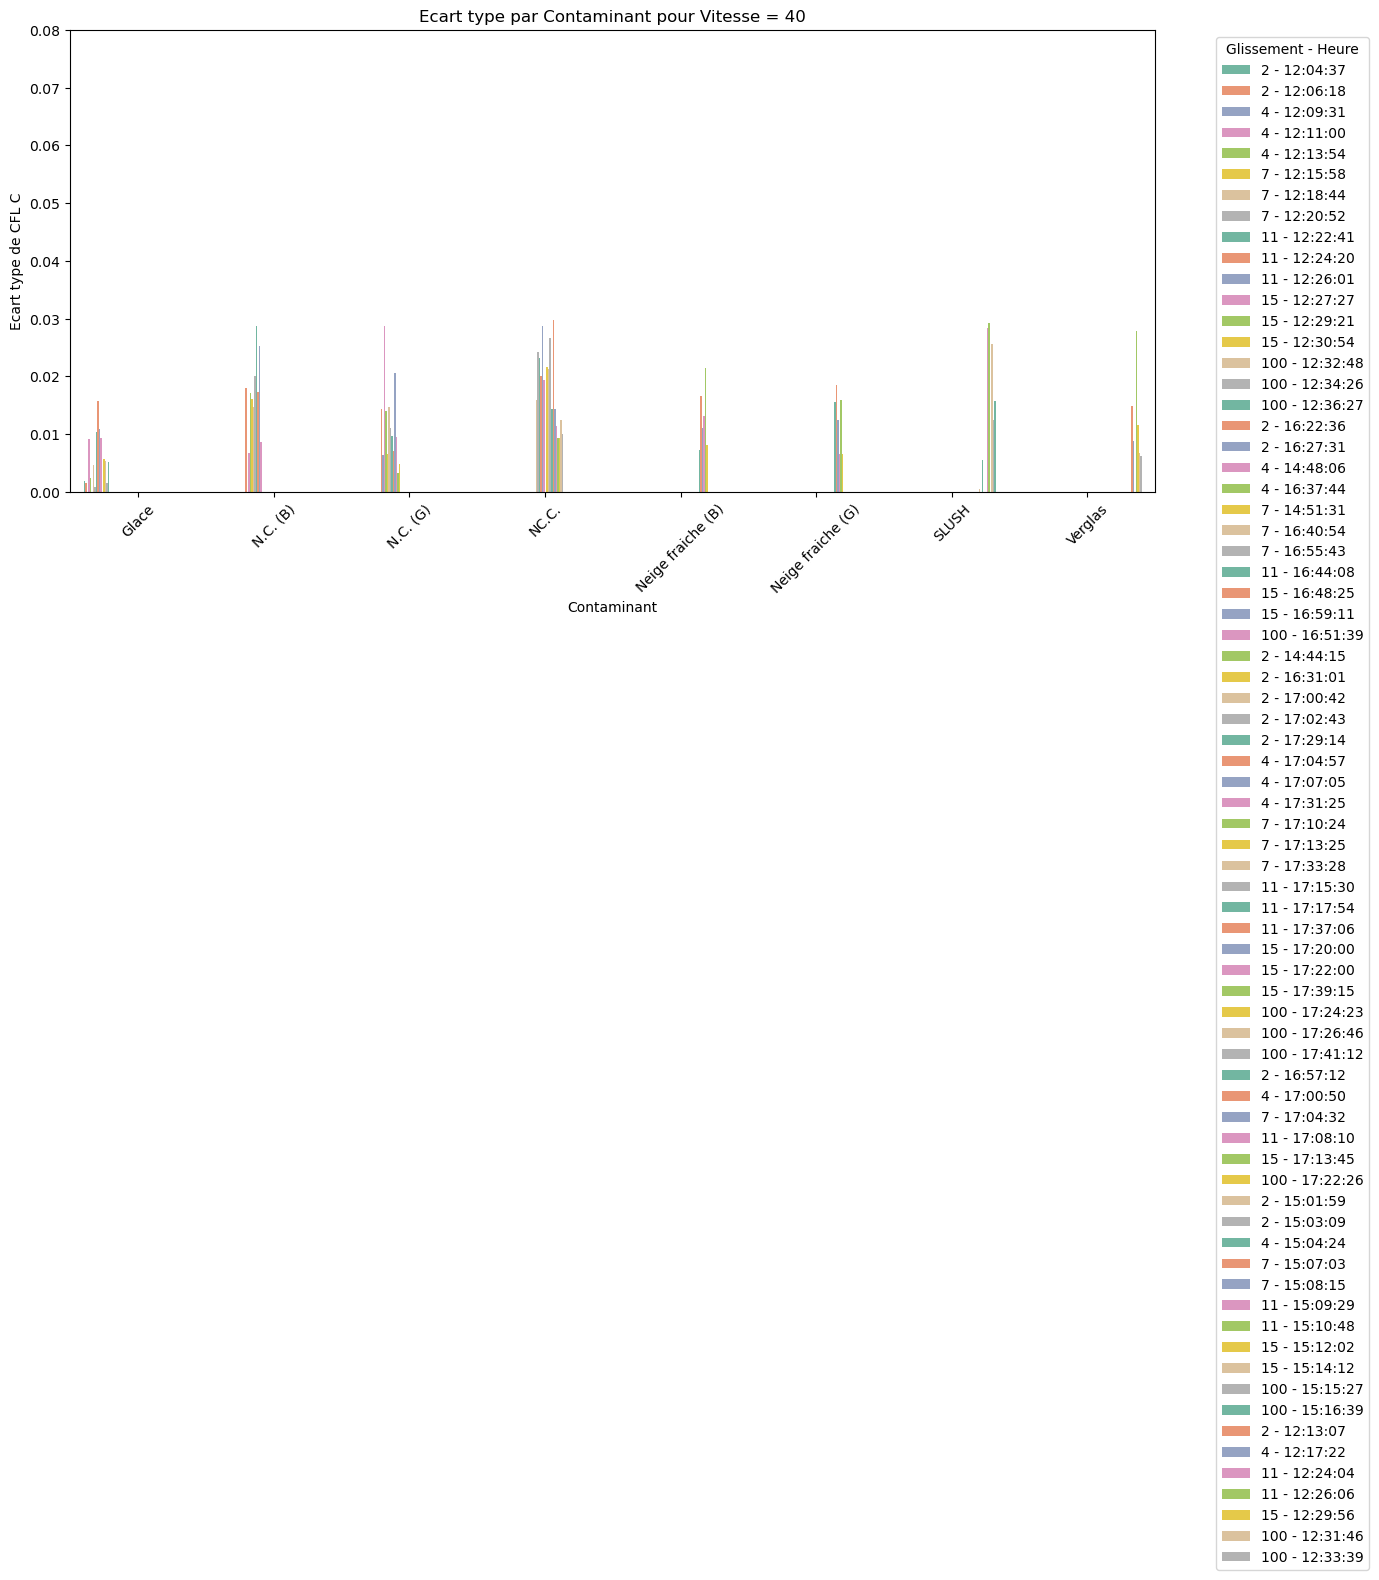

In [191]:
Reproductibilite(40)

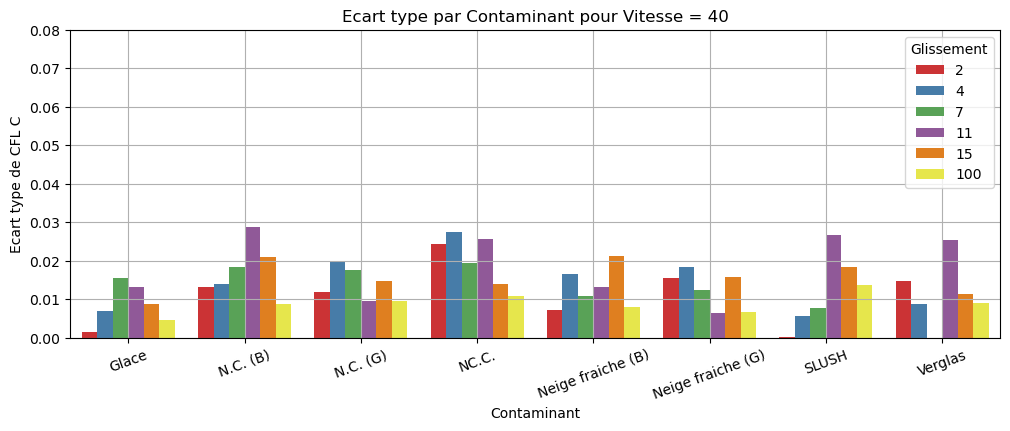

In [854]:
repeta(40)

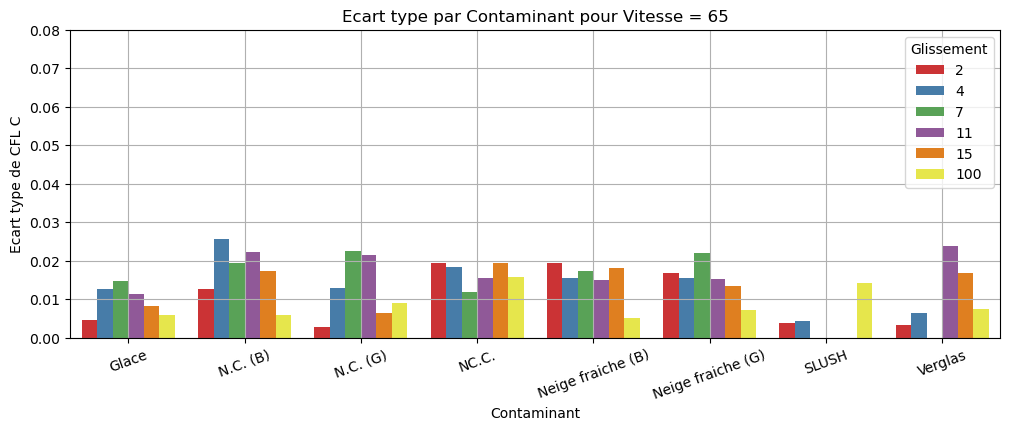

In [855]:
repeta(65)

## 
Supprimer les observations [1835, 1836, 832, 917, 918, 949, 960, 961, 962, 988, 992, 1044, 1188, 1187, 1142, 1546, 33, 50, 51, 1886, 1935, 1989, 840, 843, 872, 1998, 1997, 1994, 1995, 837, 850, 1135, 1181, 1325, 1403, 1460, 1551, 1472, 1473, 1780, 1785, 2041, 2042, 1815, 2068 de la data initiale 

In [856]:
df_grouped_rp = df_valide.groupby(['Contaminant', 'Vitesse', 'Glissement',"Heure"])['Moyenne CFL C'].agg(
        mean=np.mean,
        std=np.std,
    ).fillna(0)
df_grouped_rp['Seuil'] = df_grouped_rp['mean'].apply(seuil)
df_grouped_rp.loc[df_grouped_rp['std']> df_grouped_rp['Seuil']]

,,,,mean,std,Seuil
Contaminant,Vitesse,Glissement,Heure,,,


In [857]:
df_grouped_rp = df_valide.groupby(['Contaminant', 'Vitesse', 'Glissement'])['Moyenne CFL C'].agg(
        mean=np.mean,
        std=np.std,
    ).fillna(0)
df_grouped_rp['Seuil'] = df_grouped_rp['mean'].apply(seuil)
df_grouped_rp.loc[df_grouped_rp['std']> df_grouped_rp['Seuil']]

,,,mean,std,Seuil
Contaminant,Vitesse,Glissement,,,


In [858]:
data = data.drop(l)

In [859]:
data.to_csv("data_repeta_reprod-3.csv", index=False)

In [860]:
data.shape

(2039, 33)

In [861]:
data.columns

Index(['Machine', 'Pneumatique', 'Vitesse', 'Nom du Curseur',
       'Seuil de départ', 'Position/Axe', 'Décalage/Axe', 'Date', 'Date_txt',
       'Heure', 'Heure_txt', 'Glissement', 'Pas Min [m]', 'Pas Max [m]',
       'Moyenne Vitesse [Km/h]', 'Moyenne CFL F', 'Moyenne CFL C',
       'Moyenne G% [%]', 'Fv (kg)', 'ET G%', 'Ic G%', 'Tsurf (V)', 'ET CFLF',
       'ET CFLC', 'Ic CFL C', 'ET Fv', 'Ic Fv', 'T° BDR (V)', 'Contaminant',
       'hauteur (mm)', 'Test', '180 - Fv', 'Test_2'],
      dtype='object')

In [862]:
data[data["Test_2"]=="Valide"].groupby(['Contaminant', 'Vitesse', 'Glissement'])['Moyenne CFL C'].agg(
        count="count",
    ).fillna(0)

count
Contaminant       Vitesse Glissement       
DRY               40      0               4
                          2               2
                          4               1
                          11              1
                  65      0               4
                          2               3
                          4               2
                          11              1
                          15              1
Glace             40      2              10
                          4              13
                          7               5
                          11             10
                          15              9
                          100            11
                  65      2               8
                          4               9
                          7               3
                          11              9
                          15             10
                          100            10
N.C. (B)          40      2              11
                          4              13
                          7              15
                          11              7
                          15             12
                          100             7
                  65      2              11
                          4               4
                          7              10
                          11             15
                          15             14
                          100            21
N.C. (G)          40      2              12
                          4              10
                          7               8
                          11              5
                          15             10
                          100             7
                  65      2               4
                          4               4
                          7              10
                          11             11
                          15              8
                          100            17
NC.C.             40      2              12
                          4              22
                          7              11
                          11             31
                          15             16
                          100            33
                  65      2               9
                          4              15
                          7              13
                          11             19
                          15             21
                          100            30
Neige fraiche (B) 40      2               5
                          4               7
                          7               6
                          11             14
                          15             11
                          100            20
                  65      2              24
                          4              29
                          7              23
                          11             25
                          15             17
                          100            10
Neige fraiche (G) 40      2               4
                          4               2
                          7               5
                          11              6
                          15              6
                          100            18
                  65      2              15
                          4              16
                          7               9
                          11             17
                          15             15
                          100            16
SLUSH             40      2              14
                          4              11
                          7               3
                          11              6
                          15              3
                          100            11
                  65      2               4
                          4               5
                          7       

In [863]:
def count_(vitesse):
    # Calculer l'écart-type des groupes et renommer la colonne résultante en 'Écart-Type-CFL C'
    df_grouped = data[data["Test_2"]=="Valide"].groupby(['Contaminant', 'Vitesse', 'Glissement'])['Moyenne CFL C'].agg(
    count="count"
    ).fillna(0).reset_index()
    # Filtrer pour une vitesse donnée (par exemple 40)
    vitesse_donnee = vitesse

    df_filtered = df_grouped[df_grouped['Vitesse'] == vitesse_donnee]
    
    # Convertir les colonnes 'Glissement' et 'Heure' en type chaîne de caractères
    df_filtered['Glissement'] = df_filtered['Glissement'].astype(str)    
    # Configuration du graphique
    plt.figure(figsize=(12, 5))
    sns.barplot(data=df_filtered, x='Contaminant', y='count', hue='Glissement', palette='Set1')
    
    # Ajouter des labels et un titre
    plt.xlabel('Contaminant')
    plt.ylabel('Ecart type de CFL C')
    plt.title(f'Ecart type par Contaminant pour Vitesse = {vitesse_donnee}')
    plt.legend(title='Glissement',bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.grid(True)
    
    # Définir les limites de l'axe y
    plt.ylim(0, 20)  # Ajustez le facteur selon vos besoins
    plt.axhline(y=1, color='red', linestyle='--', linewidth=2, label='y=1')
    plt.legend(title='Glissement',bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()


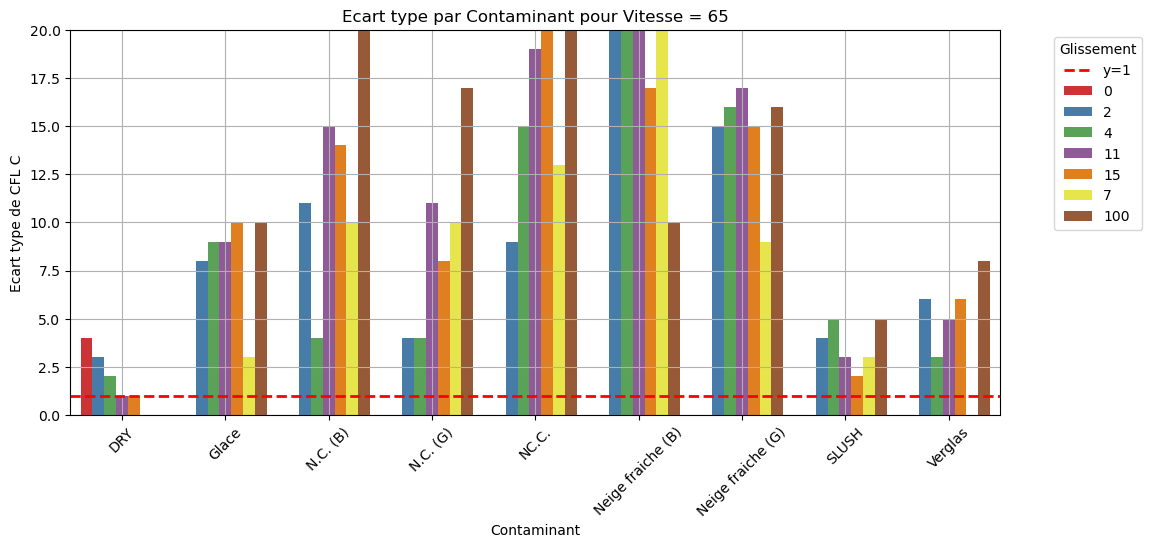

In [864]:
count_(65)

In [867]:
len(l)

105